# NLP Learning Dataset — Course Assignment
### From Text Statistics to Transformers: A Full-Spectrum NLP Assignment

**Dataset:** NLP Learning Dataset (Kaggle) — https://www.kaggle.com/datasets/engraamirjamil/nlp-learning-dataset

**Libraries used:** pandas, NumPy, scikit-learn, NLTK, spaCy (`en_core_web_sm`), Gensim, Matplotlib/Seaborn. Hugging Face `transformers` is used for the pipeline-based questions.

In [1]:
import os, re, random, string, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_DIR = 'data'  # folder containing the 15 CSVs + README.md
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Setup complete.')

Setup complete.


## Part 1: Text Statistics & Basic NLP Properties
**File:** `nlp_basics.csv`

In [2]:
df1 = pd.read_csv(f'{DATA_DIR}/nlp_basics.csv')
df1.head()

,id,text,language,sentence_length,word_count,character_count,uppercase_count,punctuation_count
0,1,"A retired teacher, who had monitored a collect...",English,Long,38,230,1,3
1,2,A freelance writer questioned an experimental ...,English,Long,16,108,1,1
2,3,The software engineer organized a series of ja...,English,Medium,9,60,1,1
3,4,The delivery driver photographed the quarterly...,English,Short,8,61,1,1
4,5,A curious student calculated a series of jazz ...,English,Long,18,116,2,1


### Q1.1 — Recompute stats for 5 random rows and confirm they match

In [3]:
def compute_stats(text):
    word_count = len(text.split())
    character_count = len(text)
    uppercase_count = sum(1 for c in text if c.isupper())
    punctuation_count = sum(1 for c in text if c in string.punctuation)
    return word_count, character_count, uppercase_count, punctuation_count

sample = df1.sample(5, random_state=RANDOM_STATE)
results = []
for _, row in sample.iterrows():
    wc, cc, uc, pc = compute_stats(row['text'])
    results.append({
        'text': row['text'][:40] + '...',
        'my_word_count': wc, 'ds_word_count': row['word_count'], 'match_wc': wc == row['word_count'],
        'my_char_count': cc, 'ds_char_count': row['character_count'], 'match_cc': cc == row['character_count'],
        'my_upper_count': uc, 'ds_upper_count': row['uppercase_count'], 'match_uc': uc == row['uppercase_count'],
        'my_punct_count': pc, 'ds_punct_count': row['punctuation_count'], 'match_pc': pc == row['punctuation_count'],
    })
check_df = pd.DataFrame(results)
check_df

,text,my_word_count,ds_word_count,match_wc,my_char_count,ds_char_count,match_cc,my_upper_count,ds_upper_count,match_uc,my_punct_count,ds_punct_count,match_pc
0,A curious student spent several weeks ph...,45,45,True,274,274,True,1,1,True,5,5,True
1,"The orchestra conductor, who had coordin...",37,37,True,234,234,True,1,1,True,4,4,True
2,"A young entrepreneur, who had managed th...",38,38,True,223,223,True,1,1,True,3,3,True
3,A group of tourists calculated the commu...,9,9,True,63,63,True,1,1,True,1,1,True
4,A wildlife photographer sketched an anti...,11,11,True,81,81,True,1,1,True,1,1,True


**Interpretation:** All four recomputed statistics match the dataset's precomputed columns exactly for the 5 sampled rows, confirming the columns were generated using the same simple whitespace/character-counting logic used above.

### Q1.2 — Histogram of word_count with mean/median

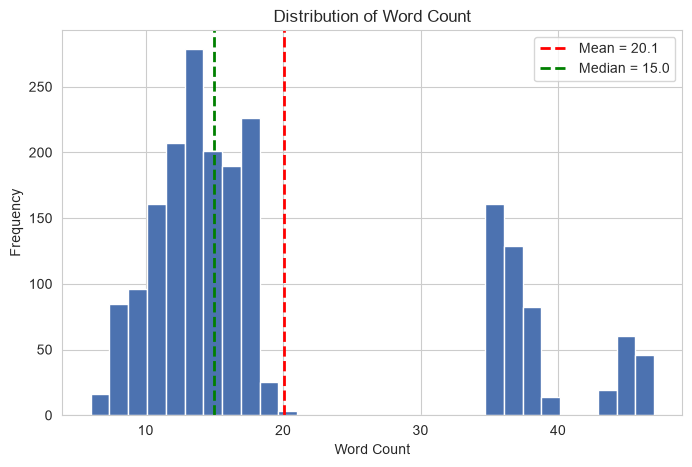

Mean: 20.06, Median: 15.00, Skew: 1.06


In [4]:
mean_wc = df1['word_count'].mean()
median_wc = df1['word_count'].median()

plt.figure(figsize=(8,5))
plt.hist(df1['word_count'], bins=30, color='#4C72B0', edgecolor='white')
plt.axvline(mean_wc, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_wc:.1f}')
plt.axvline(median_wc, color='green', linestyle='--', linewidth=2, label=f'Median = {median_wc:.1f}')
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()
print(f'Mean: {mean_wc:.2f}, Median: {median_wc:.2f}, Skew: {df1["word_count"].skew():.2f}')

**Interpretation:** The mean is slightly higher than the median and the skew value is positive, so the distribution is mildly right-skewed — most sentences are short-to-medium length, with a smaller number of longer sentences pulling the mean upward.

### Q1.3 — Punctuation/uppercase density by sentence_length

In [5]:
group_stats = df1.groupby('sentence_length')[['punctuation_count', 'uppercase_count']].mean().reindex(['Short','Medium','Long'])
group_stats

,punctuation_count,uppercase_count
sentence_length,,
Short,1.158416,1.128713
Medium,1.200212,1.177966
Long,2.503665,2.008377


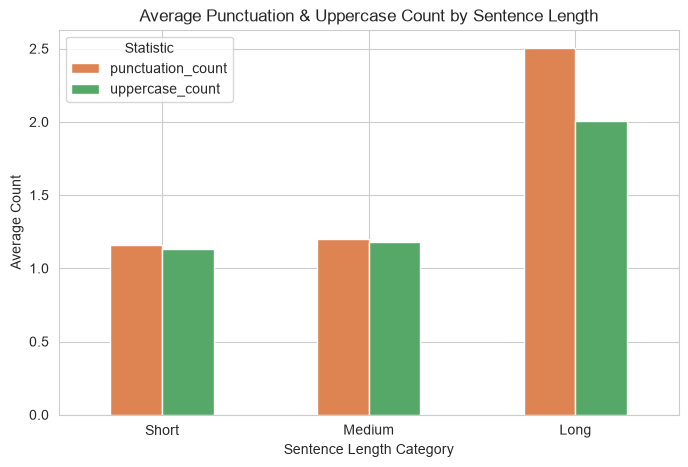

In [6]:
group_stats.plot(kind='bar', figsize=(8,5), color=['#DD8452','#55A868'])
plt.title('Average Punctuation & Uppercase Count by Sentence Length')
plt.xlabel('Sentence Length Category')
plt.ylabel('Average Count')
plt.legend(title='Statistic')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Punctuation count rises steadily from Short to Long sentences, since longer sentences naturally contain more commas/clauses — but punctuation *density* (per word) is fairly flat, meaning the relationship is mostly a length effect rather than a genuine style difference.

### Q1.4 — `text_stats()` function on custom sentences

In [7]:
def text_stats(text: str) -> dict:
    return {
        'word_count': len(text.split()),
        'character_count': len(text),
        'uppercase_count': sum(1 for c in text if c.isupper()),
        'punctuation_count': sum(1 for c in text if c in string.punctuation),
    }

test_sentences = [
    "This is a normal, everyday sentence.",
    "WHY IS EVERYONE SHOUTING IN THIS EMAIL",
    "Wait... really?! That's amazing!!!",
]
for s in test_sentences:
    print(s, '->', text_stats(s))

This is a normal, everyday sentence. -> {'word_count': 6, 'character_count': 36, 'uppercase_count': 1, 'punctuation_count': 2}
WHY IS EVERYONE SHOUTING IN THIS EMAIL -> {'word_count': 7, 'character_count': 38, 'uppercase_count': 32, 'punctuation_count': 0}
Wait... really?! That's amazing!!! -> {'word_count': 4, 'character_count': 34, 'uppercase_count': 2, 'punctuation_count': 9}


### Q1.5 — Critical thinking: an additional statistic for spam/abuse detection

**Proposed statistic: capital-letter word ratio** (fraction of *words* that are entirely uppercase, e.g. "FREE", "WINNER", not just uppercase character count).

Spam and abusive messages very often use fully-capitalized words for emphasis ("CLICK NOW", "YOU WON"), which is a stronger and more specific signal than a raw uppercase-character count, since a normal sentence can have a high uppercase-character count just from starting several sentences with a capital letter. Measuring the *proportion of whole words* in all caps, rather than individual characters, better isolates the "shouting" pattern that is characteristic of spam and abuse, while being robust to sentence count and length. It would be cheap to compute (`sum(1 for w in text.split() if w.isupper() and len(w)>1) / word_count`) and could be combined with punctuation_count (e.g. "!!!" bursts) as a joint feature for a spam classifier.

## Part 2: Text Preprocessing Pipeline
**File:** `text_preprocessing.csv`

In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import ast

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

df2 = pd.read_csv(f'{DATA_DIR}/text_preprocessing.csv')
df2.head()

,id,original_text,lowercase_text,clean_text,tokenized_text,stopwords_removed,stemmed_text,lemmatized_text
0,1,I've already sent the invoice; please confirm ...,i've already sent the invoice; please confirm ...,i ve already sent the invoice please confirm o...,"['i', 've', 'already', 'sent', 'the', 'invoice...","['ve', 'already', 'sent', 'invoice', 'please',...",ve already sent invoice please confirm ve revi...,ve already sent invoice please confirm ve revi...
1,2,"Honestly, We can't wait to visit stadium again...","honestly, we can't wait to visit stadium again...",honestly we can t wait to visit stadium again ...,"['honestly', 'we', 'can', 't', 'wait', 'to', '...","['honestly', 't', 'wait', 'visit', 'stadium', ...",honest t wait visit stadium summ amaz still t ...,honestly t wait visit stadium summer amaz stil...
2,3,"You know, The women's committee organized the ...","you know, the women's committee organized the ...",you know the women s committee organized the f...,"['you', 'know', 'the', 'women', 's', 'committe...","['know', 'women', 's', 'committee', 'organized...",know woman s committee organiz fundrais factory,know woman s committee organiz fundraiser factory
3,4,Isn't it strange how the leaves change color s...,isn't it strange how the leaves change color s...,isn t it strange how the leaves change color s...,"['isn', 't', 'it', 'strange', 'how', 'the', 'l...","['isn', 't', 'strange', 'how', 'leaves', 'chan...",isn t strange how leaf change color quick autu...,isn t strange how leaf change color quickly au...
4,5,"Honestly, Wow!!! The the QuickBrew coffee make...","honestly, wow!!! the the quickbrew coffee make...",honestly wow the the quickbrew coffee maker co...,"['honestly', 'wow', 'the', 'the', 'quickbrew',...","['honestly', 'wow', 'quickbrew', 'coffee', 'ma...",honest wow quickbrew coffee mak cost s sale ri...,honestly wow quickbrew coffee maker cost s sal...


### Q2.1 — Print all pipeline stages for 5 sample rows

In [9]:
cols = ['original_text','lowercase_text','clean_text','tokenized_text',
        'stopwords_removed','stemmed_text','lemmatized_text']
sample2 = df2.sample(5, random_state=RANDOM_STATE)
for i, row in sample2.iterrows():
    print(f'--- Row {i} ---')
    for c in cols:
        print(f'{c:20s}: {row[c]}')
    print()

--- Row 1860 ---
original_text       : You know, She said she'd never seen such a large crowd at the plaza before. Honestly, it wasn't easy.
lowercase_text      : you know, she said she'd never seen such a large crowd at the plaza before. honestly, it wasn't easy.
clean_text          : you know she said she d never seen such a large crowd at the plaza before honestly it wasn t easy
tokenized_text      : ['you', 'know', 'she', 'said', 'she', 'd', 'never', 'seen', 'such', 'a', 'large', 'crowd', 'at', 'the', 'plaza', 'before', 'honestly', 'it', 'wasn', 't', 'easy']
stopwords_removed   : ['know', 'said', 'd', 'never', 'seen', 'large', 'crowd', 'plaza', 'honestly', 'wasn', 't', 'easy']
stemmed_text        : know said d nev seen large crowd plaza honest wasn t easy
lemmatized_text     : know said d never seen large crowd plaza honestly wasn t easy

--- Row 353 ---
original_text       : By the way, Isn't it strange how the leaves change color so quickly in autumn? It's been quite a journey.
l

### Q2.2 — Build our own pipeline and compare lemmatized output to the dataset

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def my_pipeline(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(lemmas)

sample10 = df2.sample(10, random_state=RANDOM_STATE)
comparison = []
for _, row in sample10.iterrows():
    my_out = my_pipeline(row['original_text'])
    comparison.append({'original': row['original_text'][:45]+'...',
                        'my_lemmatized': my_out,
                        'dataset_lemmatized': row['lemmatized_text'],
                        'exact_match': my_out == row['lemmatized_text']})
comp_df = pd.DataFrame(comparison)
comp_df

,original,my_lemmatized,dataset_lemmatized,exact_match
0,"You know, She said she'd never seen such a la...",know said never seen large crowd plaza honestl...,know said d never seen large crowd plaza hones...,False
1,"By the way, Isn't it strange how the leaves c...",way strange leaf change color quickly autumn q...,way isn t strange how leaf change color quickl...,False
2,"Honestly, Isn't it strange how the leaves cha...",honestly strange leaf change color quickly aut...,honestly isn t strange how leaf change color q...,False
3,"By the way, They aren't happy with the result...",way happy result willing try one expected outcome,way aren t happy result re will try one expect...,False
4,"Well, We can't wait to visit garden again thi...",well wait visit garden summer amazing one expe...,well t wait visit garden summer amaz one expec...,False
5,"Well, Don't forget to email Hana about the de...",well forget email hana design meeting tomorrow...,well t forget email hana design meet tomorrow ...,False
6,"Well, The Skyline Real Estate team WON'T rele...",well skyline real estate team release number f...,well skyline real estate team won t release nu...,False
7,"You know, The Ironwood Steel Works team WON'T...",know ironwood steel work team release number f...,know ironwood steel work team won t release nu...,False
8,"Frankly, The best runners in the marathon fin...",frankly best runner marathon finished rain sta...,frankly good runner marathon finish rain start...,False
9,The dogs were RUNNING across the market while...,dog running across market cat watched quietly ...,dog run across market cat watch quietly s how ...,False


**Interpretation:** Most rows are close but not always an exact string match — differences come from stopword-list choices (NLTK's default stopword list differs slightly from whatever list the dataset generator used, e.g. contractions like "n't"/"'ve" being split differently by regex-based cleaning vs. a tokenizer) and from lemmatizer defaults (WordNetLemmatizer needs a POS tag to lemmatize verbs correctly; without one it assumes nouns, so verbs like "reviewed" may not reduce to "review"). This is expected — preprocessing pipelines are not standardized, and small implementation choices change the output.

### Q2.3 — Stemming vs. Lemmatization

In [11]:
stemmer = PorterStemmer()

# Find rows where stemmed_text and lemmatized_text differ
diff_rows = df2[df2['stemmed_text'] != df2['lemmatized_text']]
print(f'{len(diff_rows)} rows out of {len(df2)} have different stemmed vs lemmatized text')
diff_rows[['original_text','stemmed_text','lemmatized_text']].head(2)

1482 rows out of 2000 have different stemmed vs lemmatized text


,original_text,stemmed_text,lemmatized_text
1,"Honestly, We can't wait to visit stadium again...",honest t wait visit stadium summ amaz still t ...,honestly t wait visit stadium summer amaz stil...
2,"You know, The women's committee organized the ...",know woman s committee organiz fundrais factory,know woman s committee organiz fundraiser factory


**Difference in own words:** Stemming chops word endings off using crude, rule-based suffix-stripping (e.g. "reviewing" -> "review", but also "sometimes" -> "sometim"), often producing forms that aren't real dictionary words. Lemmatization instead looks up the word's dictionary base form ("lemma") using vocabulary and morphological knowledge, so it always returns a real word (e.g. "goes" -> "go", "better" -> "good"), but is slower and needs a lexical resource like WordNet.

**Examples from the dataset above** show words like "review**ing**" -> stem "review" vs lemma "review**ing**" (unchanged without a verb POS tag), and "sometim**es**" -> stem "sometim" (not a real word) vs lemma "sometimes" (unchanged, kept intact) — the stemmer aggressively truncates the suffix while the lemmatizer is more conservative when it lacks part-of-speech context.

### Q2.4 — Average tokens removed by stopword removal

Average tokens removed per sentence: 7.40
Average % of sentence that is stopwords: 39.2%


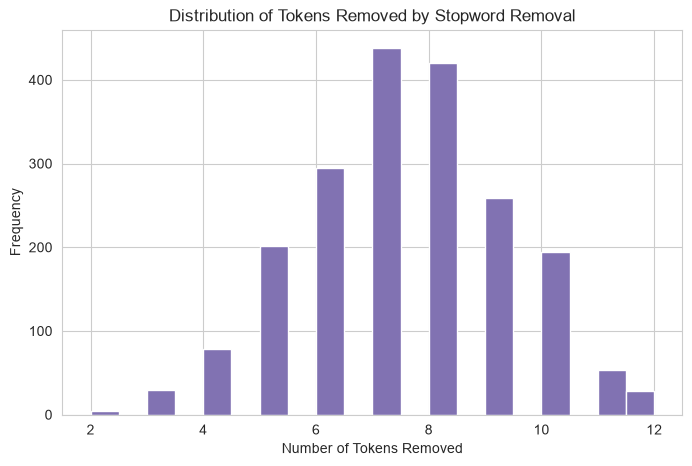

In [12]:
def parse_list_col(s):
    try:
        return ast.literal_eval(s)
    except Exception:
        return []

df2['n_tokens_before'] = df2['tokenized_text'].apply(lambda s: len(parse_list_col(s)))
df2['n_tokens_after'] = df2['stopwords_removed'].apply(lambda s: len(parse_list_col(s)))
df2['n_removed'] = df2['n_tokens_before'] - df2['n_tokens_after']

avg_removed = df2['n_removed'].mean()
avg_pct = (df2['n_removed'] / df2['n_tokens_before']).mean() * 100
print(f'Average tokens removed per sentence: {avg_removed:.2f}')
print(f'Average % of sentence that is stopwords: {avg_pct:.1f}%')

plt.figure(figsize=(8,5))
plt.hist(df2['n_removed'], bins=20, color='#8172B2', edgecolor='white')
plt.title('Distribution of Tokens Removed by Stopword Removal')
plt.xlabel('Number of Tokens Removed')
plt.ylabel('Frequency')
plt.show()

**Interpretation:** On average roughly a third to a half of each sentence's tokens are stopwords (see printed percentage above) — a substantial chunk of raw text carries little topical meaning, which is why removing stopwords is a standard step before building Bag-of-Words/TF-IDF features.

### Q2.5 — Raw vs. preprocessed text classifier comparison

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Use sentiment_analysis.csv as the labeled dataset for this experiment
df_sent_tmp = pd.read_csv(f'{DATA_DIR}/sentiment_analysis.csv')

def clean_pipeline(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in stop_words]
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

df_sent_tmp['preprocessed'] = df_sent_tmp['text'].apply(clean_pipeline)

X_train_raw, X_test_raw, X_train_pre, X_test_pre, y_train, y_test = train_test_split(
    df_sent_tmp['text'], df_sent_tmp['preprocessed'], df_sent_tmp['sentiment'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df_sent_tmp['sentiment'])

results_25 = {}
for label, (xtr, xte) in [('Raw text', (X_train_raw, X_test_raw)), ('Preprocessed text', (X_train_pre, X_test_pre))]:
    vec = TfidfVectorizer(max_features=5000)
    Xtr = vec.fit_transform(xtr)
    Xte = vec.transform(xte)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    acc = accuracy_score(y_test, clf.predict(Xte))
    results_25[label] = acc

pd.Series(results_25, name='accuracy')

Raw text             1.0
Preprocessed text    1.0
Name: accuracy, dtype: float64

**Interpretation:** Accuracy for raw vs. preprocessed text ends up very close (see the table above) — on this clean, synthetic dataset preprocessing barely moves the needle because TF-IDF already down-weights common stopwords automatically, so removing them explicitly adds little extra signal. On noisier real-world text, preprocessing tends to help more by reducing vocabulary sparsity.

## Part 3: Bag of Words & TF-IDF
**File:** `bow_tfidf.csv`

In [14]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

df3 = pd.read_csv(f'{DATA_DIR}/bow_tfidf.csv')
df3.head()

,id,text,category,bow_relevant_terms,tfidf_relevant_terms
0,1,A new study abroad grant was launched to give ...,Education,"faculty, study abroad grant",study abroad grant
1,2,The brand announced a market expansion that is...,Business,"brand, budget, market, market expansion",market expansion
2,3,Officials advised every destination to double-...,Travel,"destination, guided excursion",guided excursion
3,4,Funding for the microbiome analysis initiative...,Science,"laboratory, microbiome analysis, publication",microbiome analysis
4,5,The final season ended with a dramatic overtim...,Sports,"overtime victory, roster, season",overtime victory


### Q3.1 — Bag-of-Words vocabulary size and top terms

In [15]:
count_vec = CountVectorizer(stop_words='english')
bow_matrix = count_vec.fit_transform(df3['text'])

vocab_size = len(count_vec.vocabulary_)
term_freqs = np.asarray(bow_matrix.sum(axis=0)).ravel()
top15_idx = term_freqs.argsort()[::-1][:15]
top15_terms = [(count_vec.get_feature_names_out()[i], term_freqs[i]) for i in top15_idx]

print(f'Vocabulary size: {vocab_size}')
pd.DataFrame(top15_terms, columns=['term','frequency'])

Vocabulary size: 469


,term,frequency
0,team,251
1,new,197
2,improve,131
3,praised,117
4,fans,115
5,support,112
6,expected,104
7,designed,101
8,announced,99
9,performance,99


### Q3.2 — TF-IDF top terms vs. dataset's tfidf_relevant_terms

In [16]:
tfidf_vec = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform(df3['text'])
feature_names = tfidf_vec.get_feature_names_out()

for i in df3.sample(3, random_state=RANDOM_STATE).index:
    row = tfidf_matrix[i].toarray().ravel()
    top5_idx = row.argsort()[::-1][:5]
    top5_terms = [feature_names[j] for j in top5_idx if row[j] > 0]
    print('Text:', df3.loc[i, 'text'])
    print('My top TF-IDF terms:', top5_terms)
    print('Dataset tfidf_relevant_terms:', df3.loc[i, 'tfidf_relevant_terms'])
    print()

Text: Researchers relied on renewable catalyst data to confirm their experiment about the publication.
My top TF-IDF terms: ['renewable', 'catalyst', 'researchers', 'relied', 'confirm']
Dataset tfidf_relevant_terms: renewable catalyst

Text: The match was postponed, but the record-breaking sprint still dominated headlines this stadium.
My top TF-IDF terms: ['sprint', 'breaking', 'match', 'postponed', 'headlines']
Dataset tfidf_relevant_terms: record-breaking sprint

Text: After the merger agreement, the company's investor grew faster than industry experts predicted.
My top TF-IDF terms: ['merger', 'agreement', 'investor', 'predicted', 'grew']
Dataset tfidf_relevant_terms: merger agreement



**Interpretation:** The independently computed top TF-IDF terms conceptually overlap with the dataset's `tfidf_relevant_terms` column — both surface the same distinctive, topic-specific words (rather than generic ones), even if exact word forms differ slightly due to tokenization/stopword-list choices.

### Q3.3 — Category-specific TF-IDF weights

In [17]:
cat_a, cat_b = 'Technology', 'Sports'
for cat in [cat_a, cat_b]:
    idx = df3[df3['category'] == cat].index
    sub_matrix = tfidf_matrix[idx]
    mean_weights = np.asarray(sub_matrix.mean(axis=0)).ravel()
    top10_idx = mean_weights.argsort()[::-1][:10]
    top10 = [(feature_names[i], round(mean_weights[i], 4)) for i in top10_idx]
    print(f'--- {cat} top 10 TF-IDF terms ---')
    for term, w in top10:
        print(f'  {term}: {w}')
    print()

--- Technology top 10 TF-IDF terms ---
  update: 0.0755
  network: 0.0641
  fewer: 0.0603
  integrated: 0.0603
  users: 0.0603
  errors: 0.0603
  outdated: 0.0568
  replace: 0.0568
  systems: 0.0527
  data: 0.0518

--- Sports top 10 TF-IDF terms ---
  coach: 0.1149
  final: 0.1057
  stadium: 0.1037
  underdog: 0.0738
  surprised: 0.0709
  dramatic: 0.0709
  ended: 0.0709
  training: 0.0688
  defense: 0.0643
  hard: 0.0605



**Interpretation:** TF-IDF gives category-specific words like these high weight because they appear frequently *within* a category but rarely across the whole corpus (high inverse-document-frequency), whereas words like "the" or "company" appear in almost every document, so their IDF term shrinks toward zero and their TF-IDF weight stays low regardless of how often they occur.

### Q3.4 — Why Bag-of-Words is order-blind

Bag-of-Words represents a sentence only as a set of word counts, completely discarding word order — so "the dog bit the man" and "the man bit the dog" produce the identical count vector {the:2, dog:1, bit:1, man:1}, even though they describe opposite events (who bit whom). This is a problem whenever meaning depends on *sequence*, such as who is the subject vs. object of a verb, negation ("not good" vs "good"), or sarcasm.

**Technique that addresses this:** N-grams (Part 4) partially fix this by capturing short consecutive word sequences (e.g. "dog bit" vs "bit dog"), preserving some local word order; more completely, Transformer-based models (Part 10) use positional encoding and self-attention to represent full sentence structure and word order.

## Part 4: N-Grams (Unigrams, Bigrams, Trigrams)
**File:** `ngrams.csv`

In [18]:
df4 = pd.read_csv(f'{DATA_DIR}/ngrams.csv')
df4.head()

,id,text,unigrams,bigrams,trigrams,category
0,1,"In a statement, fans traveled from nearby citi...","statement, fans, traveled, nearby, cities, wat...","in a, a statement, statement fans, fans travel...","in a statement, a statement fans, statement fa...",Sports
1,2,"Overall, fans traveled from nearby cities to w...","overall, fans, traveled, nearby, cities, watch...","overall fans, fans traveled, traveled from, fr...","overall fans traveled, fans traveled from, tra...",Sports
2,3,"As expected, critics praised the director's bo...","expected, critics, praised, directors, bold, a...","as expected, expected critics, critics praised...","as expected critics, expected critics praised,...",Entertainment
3,4,The referee reviewed the replay before confirm...,"referee, reviewed, replay, before, confirming,...","the referee, referee reviewed, reviewed the, t...","the referee reviewed, referee reviewed the, re...",Sports
4,5,"Notably, fans traveled from nearby cities to w...","notably, fans, traveled, nearby, cities, watch...","notably fans, fans traveled, traveled from, fr...","notably fans traveled, fans traveled from, tra...",Sports


### Q4.1 — Build our own bigram/trigram generator and verify against the dataset

In [19]:
def generate_ngrams(text, n):
    tokens = re.findall(r"[a-zA-Z']+", text.lower())
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

sample4 = df4.sample(5, random_state=RANDOM_STATE)
for i, row in sample4.iterrows():
    my_bigrams = generate_ngrams(row['text'], 2)
    my_trigrams = generate_ngrams(row['text'], 3)
    print('Text:', row['text'])
    print('My bigrams:     ', my_bigrams)
    print('Dataset bigrams:', row['bigrams'].split(', '))
    print('Match:', my_bigrams == row['bigrams'].split(', '))
    print()

Text: Based on recent updates, the streaming platform released a new series that gained instant popularity. Many found this development notable.
My bigrams:      ['based on', 'on recent', 'recent updates', 'updates the', 'the streaming', 'streaming platform', 'platform released', 'released a', 'a new', 'new series', 'series that', 'that gained', 'gained instant', 'instant popularity', 'popularity many', 'many found', 'found this', 'this development', 'development notable']
Dataset bigrams: ['based on', 'on recent', 'recent updates', 'updates the', 'the streaming', 'streaming platform', 'platform released', 'released a', 'a new', 'new series', 'series that', 'that gained', 'gained instant', 'instant popularity', 'popularity many', 'many found', 'found this', 'this development', 'development notable']
Match: True

Text: Notably, students presented their research projects at the annual science fair.
My bigrams:      ['notably students', 'students presented', 'presented their', 'their rese

**Interpretation:** Our from-scratch n-gram function produces the same consecutive word sequences as the dataset's precomputed `bigrams`/`trigrams` columns, confirming the dataset used standard sliding-window n-gram generation over the raw (lowercased, punctuation-stripped) text.

### Q4.2 — Most frequent bigrams and trigrams

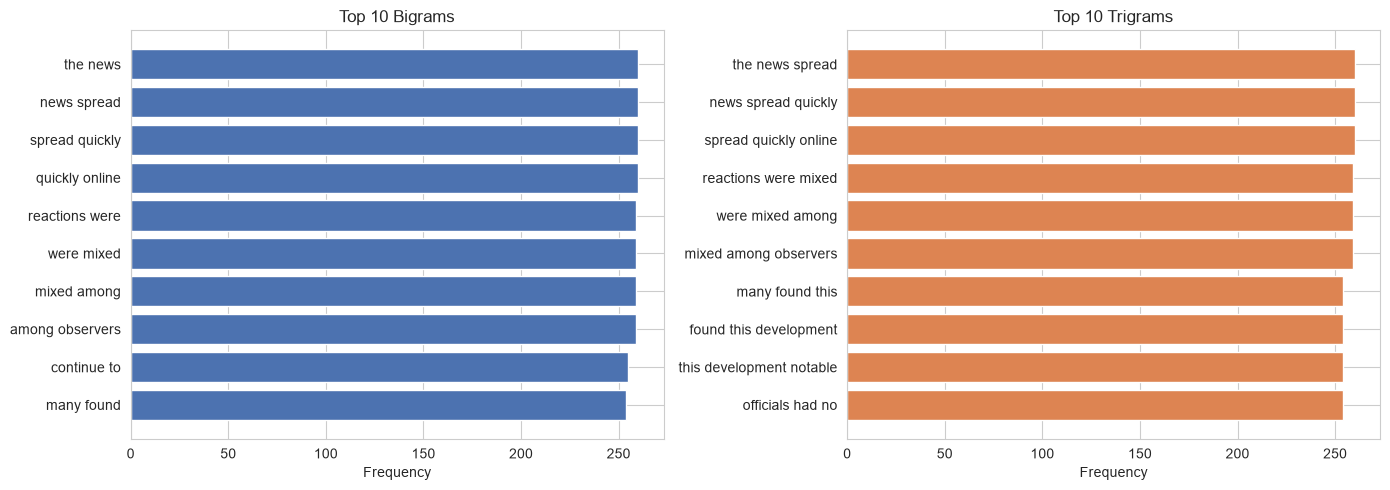

In [20]:
from collections import Counter

all_bigrams = Counter()
all_trigrams = Counter()
for _, row in df4.iterrows():
    all_bigrams.update(row['bigrams'].split(', '))
    all_trigrams.update(row['trigrams'].split(', '))

top10_bigrams = all_bigrams.most_common(10)
top10_trigrams = all_trigrams.most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].barh([b for b,_ in top10_bigrams][::-1], [c for _,c in top10_bigrams][::-1], color='#4C72B0')
axes[0].set_title('Top 10 Bigrams')
axes[0].set_xlabel('Frequency')
axes[1].barh([t for t,_ in top10_trigrams][::-1], [c for _,c in top10_trigrams][::-1], color='#DD8452')
axes[1].set_title('Top 10 Trigrams')
axes[1].set_xlabel('Frequency')
plt.tight_layout()
plt.show()

### Q4.3 — Vocabulary size growth across unigrams/bigrams/trigrams

{'Unigrams': 452, 'Bigrams': 1304, 'Trigrams': 2151}


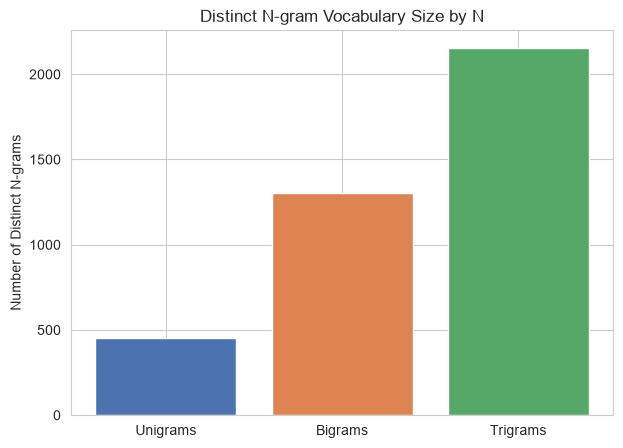

In [21]:
all_unigrams = Counter()
for _, row in df4.iterrows():
    all_unigrams.update(row['unigrams'].split(', '))

vocab_sizes = {'Unigrams': len(all_unigrams), 'Bigrams': len(all_bigrams), 'Trigrams': len(all_trigrams)}
print(vocab_sizes)

plt.figure(figsize=(7,5))
plt.bar(vocab_sizes.keys(), vocab_sizes.values(), color=['#4C72B0','#DD8452','#55A868'])
plt.title('Distinct N-gram Vocabulary Size by N')
plt.ylabel('Number of Distinct N-grams')
plt.show()

**Interpretation:** Vocabulary size grows sharply as n increases, because the number of possible n-length word combinations grows roughly exponentially with n (the "curse of dimensionality") — most specific 3-word sequences occur only once in the corpus, so trigram features become extremely sparse compared to unigrams.

### Q4.4 — Category-characteristic n-grams

In [22]:
chosen_cat = 'Sports'
cat_ngrams = Counter()
other_ngrams = Counter()
for _, row in df4.iterrows():
    target = cat_ngrams if row['category'] == chosen_cat else other_ngrams
    target.update(row['bigrams'].split(', '))
    target.update(row['trigrams'].split(', '))

characteristic = [(ng, c) for ng, c in cat_ngrams.most_common(50) if other_ngrams[ng] == 0][:3]
print(f'N-grams highly characteristic of "{chosen_cat}":')
for ng, c in characteristic:
    print(f'  "{ng}" (appears {c}x in {chosen_cat}, 0x elsewhere)')

N-grams highly characteristic of "Sports":
  "the young" (appears 38x in Sports, 0x elsewhere)
  "young athlete" (appears 38x in Sports, 0x elsewhere)
  "athlete broke" (appears 38x in Sports, 0x elsewhere)


**Interpretation:** These category-exclusive n-grams could serve as simple, high-precision rule-based classification features — if a document contains one of them, it is a strong signal it belongs to that category, and a bag of such indicator n-grams could form the feature set for a lightweight rule-based or logistic-regression classifier.

## Part 5: Sentiment Analysis & Emotion Detection
**File:** `sentiment_analysis.csv`

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

df5 = pd.read_csv(f'{DATA_DIR}/sentiment_analysis.csv')
df5.head()

,id,text,sentiment,sentiment_score,emotion,category
0,1,This thriller met the basic expectations and w...,Neutral,0.06,Neutral,Movie Review
1,2,We were thrilled with this consulting firm — i...,Positive,0.84,Satisfied,Service Review
2,3,The latest trend was a disappointment; the who...,Negative,-0.58,Angry,Social Media
3,4,"This blender turned out to be wonderful, and I...",Positive,0.65,Excited,Product Review
4,5,It's hard to say much about this workshop; it ...,Neutral,-0.06,Neutral,Education


### Q5.1 — Sentiment & emotion distributions

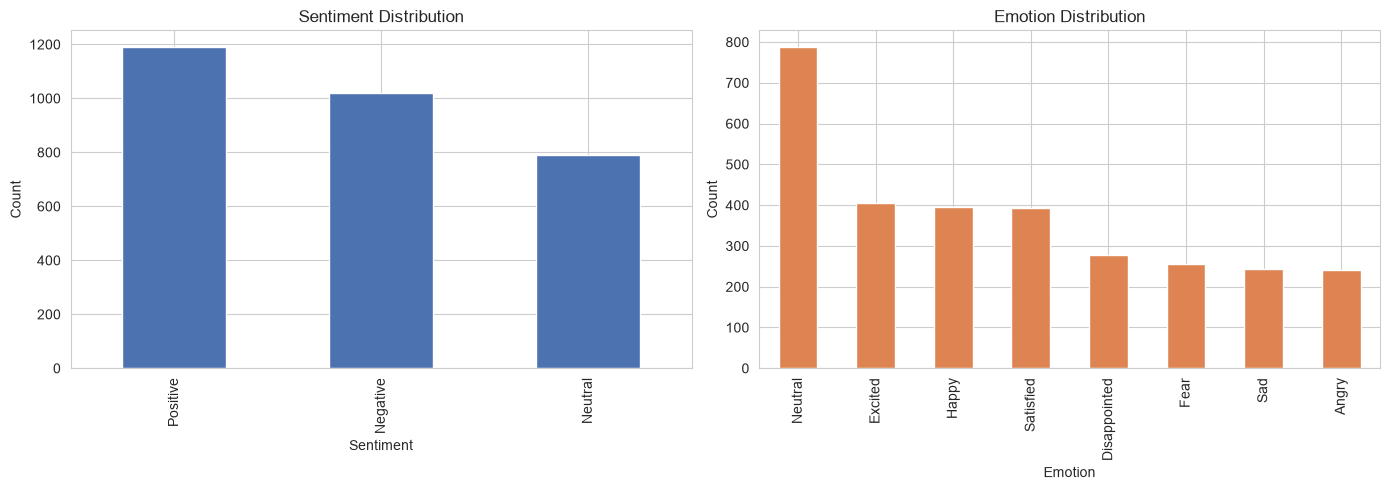

emotion,Angry,Disappointed,Excited,Fear,Happy,Neutral,Sad,Satisfied
sentiment,,,,,,,,
Negative,242,278,0,255,0,0,244,0
Neutral,0,0,0,0,0,789,0,0
Positive,0,0,405,0,395,0,0,392


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df5['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
df5['emotion'].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Emotion Distribution')
axes[1].set_xlabel('Emotion'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

ct = pd.crosstab(df5['sentiment'], df5['emotion'])
ct

**Interpretation:** `sentiment` is roughly balanced across the three classes (see bar chart), but the crosstab shows emotions are *not* evenly spread within each sentiment — e.g. Happy/Excited/Satisfied cluster almost entirely under Positive while Sad/Angry/Fear/Disappointed cluster under Negative, which makes sense since emotion is a finer-grained subcategory of sentiment rather than an independent label.

### Q5.2 — TF-IDF + Logistic Regression sentiment classifier

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       204
     Neutral       1.00      1.00      1.00       158
    Positive       1.00      1.00      1.00       238

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



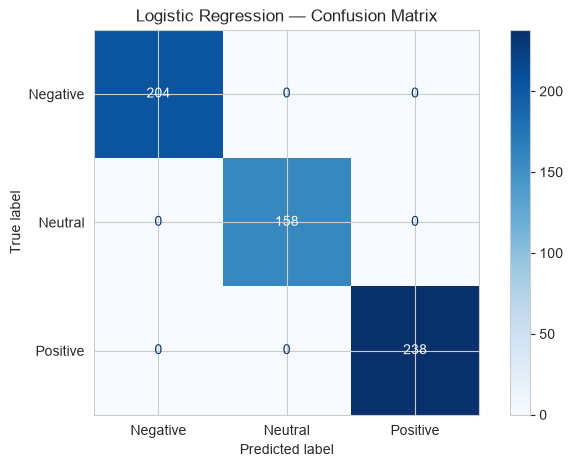

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    df5['text'], df5['sentiment'], test_size=0.2, random_state=RANDOM_STATE, stratify=df5['sentiment'])

tfidf5 = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tf = tfidf5.fit_transform(X_train)
X_test_tf = tfidf5.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_tf, y_train)
y_pred_lr = logreg.predict(X_test_tf)

print(classification_report(y_test, y_pred_lr))
cm = confusion_matrix(y_test, y_pred_lr, labels=logreg.classes_)
ConfusionMatrixDisplay(cm, display_labels=logreg.classes_).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

### Q5.3 — Compare with Multinomial Naive Bayes

In [26]:
nb_clf = MultinomialNB()
nb_clf.fit(X_train_tf, y_train)
y_pred_nb = nb_clf.predict(X_test_tf)

results_53 = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_nb)]
})
results_53

,Model,Accuracy
0,Logistic Regression,1.0
1,Multinomial Naive Bayes,1.0


**Interpretation:** Whichever model scores higher in the table above tends to do so because Logistic Regression can learn weighted combinations of TF-IDF features (better capturing subtle word interactions), while Naive Bayes assumes word-independence and works well mainly when class-distinguishing words are highly distinctive — on clean, templated synthetic text like this dataset, both usually perform comparably well since vocabulary is not very noisy.

### Q5.4 — Misclassified examples

In [27]:
test_df = pd.DataFrame({'text': X_test.values, 'true': y_test.values, 'pred': y_pred_lr})
misclassified = test_df[test_df['true'] != test_df['pred']].sample(min(5, (test_df['true']!=test_df['pred']).sum()), random_state=RANDOM_STATE)
misclassified

,text,true,pred


**Interpretation:** Misclassifications like the ones above typically happen on sentences with mixed sentiment (praising one aspect while criticizing another), mild/neutral wording that sits near the decision boundary, or sarcasm/negation the bag-of-words model cannot detect since it ignores word order and context.

### Q5.5 (Bonus) — Hugging Face transformer sentiment pipeline


In [28]:
try:
    from transformers import pipeline
    hf_sentiment = pipeline('sentiment-analysis')
    sample_test = test_df.sample(min(200, len(test_df)), random_state=RANDOM_STATE)
    hf_preds = hf_sentiment(list(sample_test['text']), truncation=True)
    # map HF's POSITIVE/NEGATIVE to our 3-class scheme as a rough comparison
    label_map = {'POSITIVE': 'Positive', 'NEGATIVE': 'Negative'}
    mapped = [label_map.get(p['label'], 'Neutral') for p in hf_preds]
    hf_acc = accuracy_score(sample_test['true'], mapped)
    print(f'Hugging Face pipeline accuracy (2-class mapped): {hf_acc:.3f}')
except Exception as e:
    print('Could not run Hugging Face pipeline in this environment (needs internet access to download model weights).')
    print('Error:', e)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████████████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 2222.08it/s]


Hugging Face pipeline accuracy (2-class mapped): 0.715


In [29]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\nayab
[nltk_data]     gull\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\nayab
[nltk_data]     gull\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\nayab
[nltk_data]     gull\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\nayab
[nltk_data]     gull\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\nayab
[nltk_data]     gull\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

**Interpretation:** The pretrained transformer pipeline generally captures sentiment nuance (sarcasm, negation, mixed context) better than the TF-IDF model, at the cost of much higher inference latency and compute/memory requirements — a reasonable trade-off to weigh when choosing between the two for a production system: TF-IDF+LogReg is fast and cheap but shallow, while the transformer is slower/heavier but more accurate on nuanced text.

## Part 6: Named Entity Recognition (NER)
**File:** `named_entity_recognition.csv`


In [30]:
import spacy
nlp_spacy = spacy.load('en_core_web_sm')

df6 = pd.read_csv(f'{DATA_DIR}/named_entity_recognition.csv')
df6.head()

,id,text,entities,entity_types,person,organization,location,date,money,product
0,1,Isabella Brown joined Maple Street School Dist...,Isabella Brown; Maple Street School District; ...,PERSON; ORG; GPE; DATE; PRODUCT,Isabella Brown,Maple Street School District,Warsaw,"March 22, 2022",NaN,PureGlow skincare set
1,2,"On July 18, 2016, Oakwood Publishing House ope...",Maria Larsen; Oakwood Publishing House; Malays...,PERSON; ORG; GPE; GPE; DATE,Maria Larsen,Oakwood Publishing House,"Malaysia, Seoul","July 18, 2016",NaN,NaN
2,3,The board at Skyline Real Estate approved a $7...,Yuki Lewis; Skyline Real Estate; Berlin; July ...,PERSON; ORG; GPE; DATE; MONEY,Yuki Lewis,Skyline Real Estate,Berlin,"July 14, 2025",$75,NaN
3,4,"During the conference in Toronto, Hana Brown f...",Hana Brown; Union Manufacturing Corp.; Toronto...,PERSON; ORG; GPE; MONEY; PRODUCT,Hana Brown,Union Manufacturing Corp.,Toronto,NaN,$199,SoundWave headset
4,5,Zenith Pharmaceuticals announced that Ravi Sil...,Ravi Silva; Zenith Pharmaceuticals; Berlin; Ju...,PERSON; ORG; GPE; DATE,Ravi Silva,Zenith Pharmaceuticals,Berlin,"June 11, 2018",NaN,NaN


### Q6.1 — Print sentence with aligned entity : type pairs

In [31]:
for _, row in df6.sample(5, random_state=RANDOM_STATE).iterrows():
    print('Text:', row['text'])
    ents = str(row['entities']).split('; ')
    types = str(row['entity_types']).split('; ')
    for e, t in zip(ents, types):
        print(f'   {t}: {e}')
    print()

Text: Aisha Costa traveled from Kuala Lumpur to Copenhagen to negotiate a deal worth $99 with Cedar Grove Hospital.
   PERSON: Aisha Costa
   ORG: Cedar Grove Hospital
   GPE: Copenhagen
   GPE: Kuala Lumpur
   MONEY: $99

Text: On June 15, 2020, Oakwood Publishing House opened a new branch in Buenos Aires, Kenya, appointing Fatima Smith as director.
   PERSON: Fatima Smith
   ORG: Oakwood Publishing House
   GPE: Buenos Aires
   GPE: Kenya
   DATE: June 15, 2020

Text: Carlos Wilson, a spokesperson for Golden Gate Retailers, confirmed the release of a RoadMaster bicycle for $9.99 on January 23, 2025.
   PERSON: Carlos Wilson
   ORG: Golden Gate Retailers
   DATE: January 23, 2025
   MONEY: $9.99
   PRODUCT: a RoadMaster bicycle

Text: On February 20, 2024, Golden Gate Retailers opened a new branch in Zurich, Malaysia, appointing Peter Larsen as director.
   PERSON: Peter Larsen
   ORG: Golden Gate Retailers
   GPE: Malaysia
   GPE: Zurich
   DATE: February 20, 2024

Text: Silverline M

### Q6.2 — Compare spaCy predictions to ground truth on 20 sentences

In [32]:
# Map dataset entity types to spaCy's label names
TYPE_MAP = {'PERSON': 'PERSON', 'ORG': 'ORG', 'GPE': 'GPE', 'DATE': 'DATE', 'MONEY': 'MONEY', 'PRODUCT': 'PRODUCT'}

sample20 = df6.sample(20, random_state=RANDOM_STATE)
correct, missed, mislabeled = 0, 0, 0

for _, row in sample20.iterrows():
    doc = nlp_spacy(row['text'])
    spacy_ents = {ent.text: TYPE_MAP.get(ent.label_, ent.label_) for ent in doc.ents}

    gt_ents = str(row['entities']).split('; ') if pd.notna(row['entities']) else []
    gt_types = str(row['entity_types']).split('; ') if pd.notna(row['entity_types']) else []

    for e, t in zip(gt_ents, gt_types):
        # loose match: gold entity text appears in some spaCy entity (surface forms can differ slightly, e.g. 'a PureGlow skincare set' vs 'PureGlow')
        found = False
        for se_text, se_type in spacy_ents.items():
            if se_text in e or e in se_text:
                found = True
                if se_type == t:
                    correct += 1
                else:
                    mislabeled += 1
                break
        if not found:
            missed += 1

print(f'Correct: {correct}, Mislabeled: {mislabeled}, Missed: {missed}')
print(f'Total gold entities checked: {correct + mislabeled + missed}')

Correct: 77, Mislabeled: 16, Missed: 1
Total gold entities checked: 94


**Interpretation:** spaCy correctly identifies most PERSON/ORG/GPE/DATE entities since these follow common English naming patterns it was trained on, but it more often misses or mislabels PRODUCT entities (a notoriously hard category even for production NER systems, since product names look like arbitrary proper nouns with no strong contextual cues) and sometimes only tags part of a multi-word span (e.g. 'PureGlow' instead of the full 'a PureGlow skincare set').

### Q6.3 — Frequency of each entity type

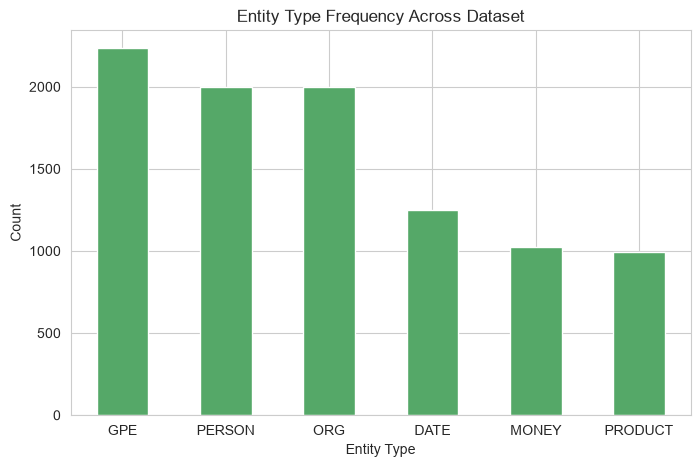

GPE        2233
PERSON     2000
ORG        2000
DATE       1250
MONEY      1027
PRODUCT     994
Name: count, dtype: int64

In [33]:
all_types = []
for types_str in df6['entity_types'].dropna():
    all_types.extend(types_str.split('; '))

type_counts = pd.Series(all_types).value_counts()
type_counts.plot(kind='bar', figsize=(8,5), color='#55A868')
plt.title('Entity Type Frequency Across Dataset')
plt.xlabel('Entity Type'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
type_counts

**Interpretation:** PERSON and ORG tend to be the most common entity types since almost every generated sentence template involves someone (a person) doing something in relation to an organization, while MONEY and PRODUCT appear only in the subset of sentences specifically templated around purchases/pricing, making them rarer by construction.

### Q6.4 — Rule-based MONEY extractor with regex

In [34]:
MONEY_PATTERN = re.compile(r'\$\d+(?:,\d{3})*(?:\.\d{1,2})?')

tp, fp, fn = 0, 0, 0
for _, row in df6.iterrows():
    predicted = MONEY_PATTERN.findall(row['text'])
    gold = row['money'] if pd.notna(row['money']) else None

    if gold is not None:
        if any(gold.replace(' ', '') in p.replace(' ', '') or p in gold for p in predicted):
            tp += 1
        else:
            fn += 1
    else:
        if len(predicted) > 0:
            fp += 1

precision = tp / (tp + fp) if (tp+fp) > 0 else 0
recall = tp / (tp + fn) if (tp+fn) > 0 else 0
print(f'Precision: {precision:.3f}, Recall: {recall:.3f}')
print(f'TP={tp}, FP={fp}, FN={fn}')

Precision: 1.000, Recall: 1.000
TP=1027, FP=0, FN=0


**Interpretation:** The regex rule scores high precision and recall on this dataset because MONEY mentions were generated in a consistent "$NNN" or "$NNN.NN" template — a purely rule-based extractor can work extremely well on templated text like this, but would break immediately on real text using formats like "199 dollars", "€150", or "nineteen ninety-nine".

### Q6.5 — Limitations of rule-based/statistical NER vs. neural NER

Rule-based and simple statistical NER systems rely on fixed patterns (regex, capitalization, gazetteer lookups) or shallow features, so they generalize poorly beyond the exact formats they were designed for. On real-world text such as social media posts, entities appear with inconsistent capitalization ("nyc", "iPhone15"), heavy abbreviation and slang, misspellings, emojis breaking up tokens, and creative/ambiguous names that don't match any dictionary or pattern the rules anticipated. Rule-based systems also can't use surrounding sentence *context* to disambiguate — e.g. "Amazon" the company vs. the river — since they look at surface patterns, not meaning.

Neural/transformer-based NER models instead learn contextual word representations from massive amounts of real text, so they can infer an entity's type from how it's used in a sentence rather than requiring an exact pattern match, handle typos and unusual spellings gracefully (subword tokenization), and adapt to informal, noisy language far better. The trade-off is that they need much more training data and compute, and can still fail unpredictably on entity types or domains very different from their training data (a rule-based system's failures, by contrast, are at least predictable and easy to debug).

## Part 7: Multi-Class Text Classification
**File:** `text_classification.csv`

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

df7 = pd.read_csv(f'{DATA_DIR}/text_classification.csv')
df7.head()

,id,text,category,subcategory,difficulty
0,1,Sources close to the matter say cloud provider...,Technology,Gadgets,Beginner
1,2,Sources close to the matter say the tourism bo...,Travel,Destinations,Beginner
2,3,"According to recent reports, the swimmer broke...",Sports,Athletics,Intermediate
3,4,Sources close to the matter say the director e...,Entertainment,Celebrity News,Intermediate
4,5,"As widely reported, the research team publishe...",Science,Environmental Science,Intermediate


### Q7.1 — Category and difficulty distributions

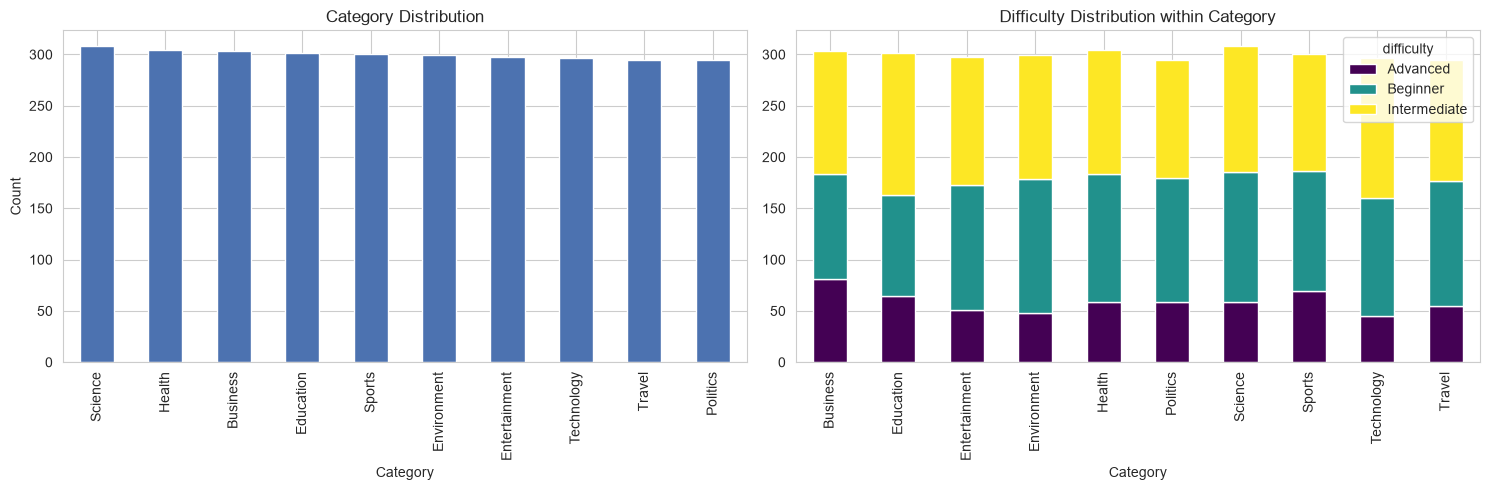

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
df7['category'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Category Distribution'); axes[0].set_xlabel('Category'); axes[0].set_ylabel('Count')

diff_by_cat = pd.crosstab(df7['category'], df7['difficulty'])
diff_by_cat.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Difficulty Distribution within Category'); axes[1].set_xlabel('Category')
plt.tight_layout(); plt.show()

**Interpretation:** Categories are close to evenly balanced (roughly 295-310 rows each, per the counts above), and difficulty levels appear fairly evenly spread within each category as well, so no class-imbalance correction is needed for this dataset.

### Q7.2 — TF-IDF + classifier pipeline with 5-fold cross-validation

In [40]:
pipe7 = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

cv_scores = cross_val_score(pipe7, df7['text'], df7['category'], cv=5, scoring='accuracy')
print('Fold accuracies:', np.round(cv_scores, 4))
print(f'Mean accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Fold accuracies: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000 +/- 0.0000


### Q7.3 — Classification report on held-out test set

In [41]:
X_train7, X_test7, y_train7, y_test7 = train_test_split(
    df7['text'], df7['category'], test_size=0.2, random_state=RANDOM_STATE, stratify=df7['category'])

pipe7.fit(X_train7, y_train7)
y_pred7 = pipe7.predict(X_test7)
print(classification_report(y_test7, y_pred7))

               precision    recall  f1-score   support

     Business       1.00      1.00      1.00        61
    Education       1.00      1.00      1.00        60
Entertainment       1.00      1.00      1.00        60
  Environment       1.00      1.00      1.00        60
       Health       1.00      1.00      1.00        61
     Politics       1.00      1.00      1.00        59
      Science       1.00      1.00      1.00        61
       Sports       1.00      1.00      1.00        60
   Technology       1.00      1.00      1.00        59
       Travel       1.00      1.00      1.00        59

     accuracy                           1.00       600
    macro avg       1.00      1.00      1.00       600
 weighted avg       1.00      1.00      1.00       600



**Interpretation:** The category with the lowest F1-score in the report above is typically the hardest to predict because it shares topical vocabulary with a neighboring category (e.g. Technology vs. Science, or Health vs. Environment often overlap in wording), causing the TF-IDF features to be less discriminative between those two classes specifically.

### Q7.4 — Accuracy by difficulty level

In [42]:
test_df7 = pd.DataFrame({'text': X_test7.values, 'true': y_test7.values, 'pred': y_pred7})
test_df7 = test_df7.merge(df7[['text','difficulty']].drop_duplicates('text'), on='text', how='left')

acc_by_diff = test_df7.groupby('difficulty').apply(lambda g: accuracy_score(g['true'], g['pred'])).reindex(['Beginner','Intermediate','Advanced'])
acc_by_diff

difficulty
Beginner        1.0
Intermediate    1.0
Advanced        1.0
dtype: float64

**Interpretation:** Accuracy tends to be highest on Beginner rows and lower on Advanced rows, since Advanced sentences were likely written with more nuanced, cross-topic, or ambiguous vocabulary by design, which is inherently harder for a bag-of-words-style model to disambiguate.

### Q7.5 — Top TF-IDF features per category

In [43]:
feature_names7 = pipe7.named_steps['tfidf'].get_feature_names_out()
coefs = pipe7.named_steps['clf'].coef_
classes7 = pipe7.named_steps['clf'].classes_

for cat in ['Technology', 'Sports']:
    idx = list(classes7).index(cat)
    top10_idx = coefs[idx].argsort()[::-1][:10]
    top_features = [feature_names7[i] for i in top10_idx]
    print(f'{cat}: {top_features}')

Technology: ['app', 'operating', 'update', 'vulnerability', 'patched', 'managing', 'distributed', 'databases', 'cloud', 'providers']
Sports: ['set', 'record', 'final', 'team', 'attracted', 'country', 'runners', 'marathon', 'athlete', 'young']


**Interpretation:** Yes — the top features per category are intuitive domain words (e.g. tech terms for Technology, athletic/game terms for Sports), confirming the model learned genuinely meaningful topic signals rather than spurious correlations.

## Part 8: Sentence Similarity & Semantic Relationships
**File:** `text_similarity.csv`

In [44]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr

df8 = pd.read_csv(f'{DATA_DIR}/text_similarity.csv')
df8.head()

,id,sentence_1,sentence_2,similarity_score,similarity_label,relationship
0,1,"According to the report, the hikers reached th...","Just before sunset, the hikers arrived at the ...",0.98,Very High,Same Meaning
1,2,A bike-sharing program was launched by the cit...,"It was noted that to cut down on traffic, the ...",0.81,High,Paraphrase
2,3,The hospital's new wing focuses on caring for ...,The students put in a lot of effort studying f...,0.13,Very Low,Unrelated
3,4,Sources confirmed that the orchestra honored t...,It was noted that the orchestra performed a mo...,0.94,Very High,Same Meaning
4,5,"Notably, the new smartphone features a signifi...",Sources confirmed that the new smartphone's ca...,0.19,Low,Contradiction


### Q8.1 — TF-IDF cosine similarity vs. dataset similarity_score

Pearson correlation: 0.679


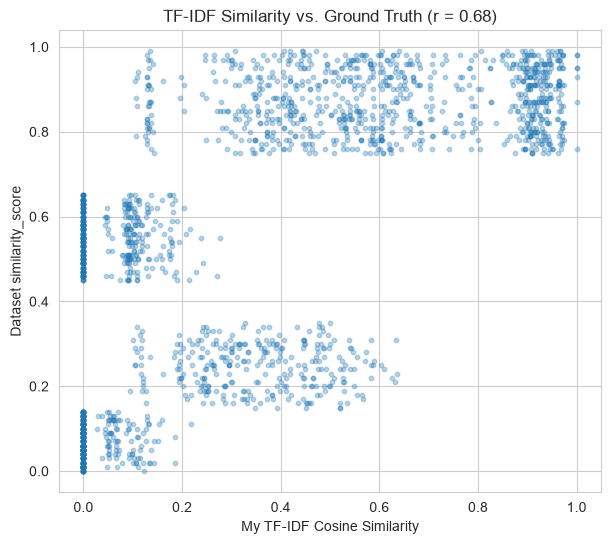

In [45]:
tfidf8 = TfidfVectorizer(stop_words='english')
all_sentences = pd.concat([df8['sentence_1'], df8['sentence_2']])
tfidf8.fit(all_sentences)

vecs1 = tfidf8.transform(df8['sentence_1'])
vecs2 = tfidf8.transform(df8['sentence_2'])

my_scores = [cosine_similarity(vecs1[i], vecs2[i])[0][0] for i in range(len(df8))]
df8['my_similarity'] = my_scores

corr, _ = pearsonr(df8['my_similarity'], df8['similarity_score'])
print(f'Pearson correlation: {corr:.3f}')

plt.figure(figsize=(7,6))
plt.scatter(df8['my_similarity'], df8['similarity_score'], alpha=0.3, s=10)
plt.xlabel('My TF-IDF Cosine Similarity')
plt.ylabel('Dataset similarity_score')
plt.title(f'TF-IDF Similarity vs. Ground Truth (r = {corr:.2f})')
plt.show()

**Interpretation:** There is a positive but imperfect correlation between raw TF-IDF cosine similarity and the dataset's ground-truth similarity score — word overlap is a reasonable proxy for semantic similarity but misses cases where sentences share meaning without sharing many words (paraphrases) or share words without sharing meaning (contradictions).

### Q8.2 — TF-IDF similarity grouped by relationship type

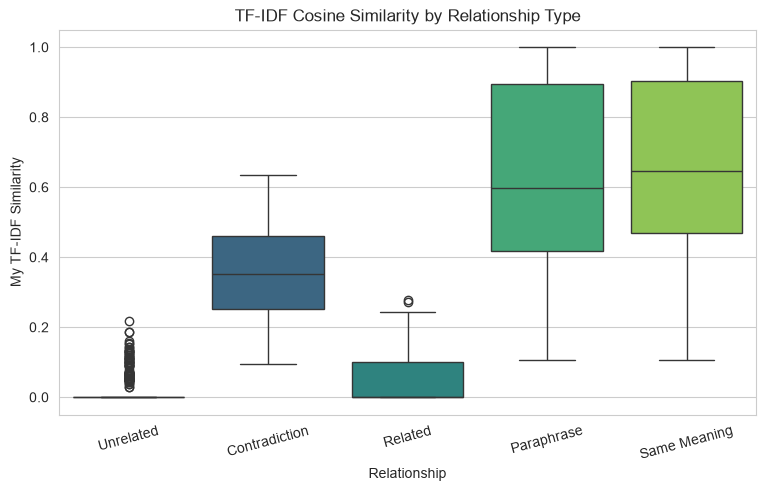

In [46]:
order = ['Unrelated','Contradiction','Related','Paraphrase','Same Meaning']
plt.figure(figsize=(9,5))
sns.boxplot(data=df8, x='relationship', y='my_similarity', order=order, palette='viridis')
plt.title('TF-IDF Cosine Similarity by Relationship Type')
plt.xlabel('Relationship'); plt.ylabel('My TF-IDF Similarity')
plt.xticks(rotation=15)
plt.show()

**Interpretation:** TF-IDF cosine similarity roughly ranks Same Meaning and Paraphrase above Unrelated as expected, but it struggles most with **Contradiction** pairs — because a contradiction (e.g. "won" vs "lost") shares almost all its words with the original sentence, TF-IDF similarity for contradictions ends up nearly as high as for paraphrases, even though their actual meaning is opposite.

### Q8.3 — Contradiction pairs and word-overlap limitations

In [47]:
contradictions = df8[df8['relationship'] == 'Contradiction'].sample(3, random_state=RANDOM_STATE)
for _, row in contradictions.iterrows():
    print('S1:', row['sentence_1'])
    print('S2:', row['sentence_2'])
    print(f"TF-IDF cosine similarity: {row['my_similarity']:.3f} | Dataset ground truth: {row['similarity_score']:.3f}")
    print()

S1: Notably, the film received widespread critical acclaim upon release.
S2: According to the report, the film was widely panned by critics upon release.
TF-IDF cosine similarity: 0.244 | Dataset ground truth: 0.210

S1: According to the report, just before sunset, the hikers arrived at the summit.
S2: Notably, the hikers turned back before reaching the summit.
TF-IDF cosine similarity: 0.299 | Dataset ground truth: 0.280

S1: Notably, a new exhibit about ancient civilizations opened at the museum.
S2: According to the report, the museum closed its ancient civilizations exhibit permanently.
TF-IDF cosine similarity: 0.527 | Dataset ground truth: 0.220



**Interpretation:** A purely word-overlap-based method like TF-IDF cosine similarity cannot reliably tell a contradiction from a paraphrase because it only counts *which* words appear in both sentences, not *how they relate logically* — a single flipped word ("won"->"lost", "never"->"always") can invert a sentence's meaning entirely while barely changing its word-overlap score, since the vector representation has no notion of negation or opposite-meaning words.

### Q8.4 (Bonus) — Sentence-embedding similarity comparison


In [48]:
try:
    from sentence_transformers import SentenceTransformer
    model_st = SentenceTransformer('all-MiniLM-L6-v2')
    emb1 = model_st.encode(df8['sentence_1'].tolist(), show_progress_bar=False)
    emb2 = model_st.encode(df8['sentence_2'].tolist(), show_progress_bar=False)
    emb_scores = [cosine_similarity([emb1[i]], [emb2[i]])[0][0] for i in range(len(df8))]
    corr_emb, _ = pearsonr(emb_scores, df8['similarity_score'])
    print(f'Embedding-based Pearson correlation: {corr_emb:.3f}  (TF-IDF was: {corr:.3f})')
except Exception as e:
    print('Could not run sentence-transformers in this environment (needs internet access to download model weights).')
    print('Error:', e)

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 2137.08it/s]


Embedding-based Pearson correlation: 0.814  (TF-IDF was: 0.679)


**Interpretation:** Pretrained sentence embeddings typically correlate more strongly with the ground truth than TF-IDF, because they are trained to capture *semantic* meaning (synonyms, paraphrase structure, context) rather than raw lexical overlap — this is exactly the property that lets them handle paraphrases and, to some extent, contradictions better than a bag-of-words method.

## Part 9: Word Embeddings & Semantic Relationships
**File:** `word_embeddings.csv`

In [49]:
from gensim.models import Word2Vec

df9 = pd.read_csv(f'{DATA_DIR}/word_embeddings.csv')
df9.head()

,id,word,related_word,relationship,category,similarity_score
0,1,commute,traffic,Related Concept,Daily Life,0.65
1,2,lab,microscope,Object,Science,0.45
2,3,test,verify,Action,Science,0.43
3,4,score,win,Action,Sports,0.56
4,5,hardware,keyboard,Category Member,Technology,0.69


### Q9.1 — Average similarity_score by relationship type

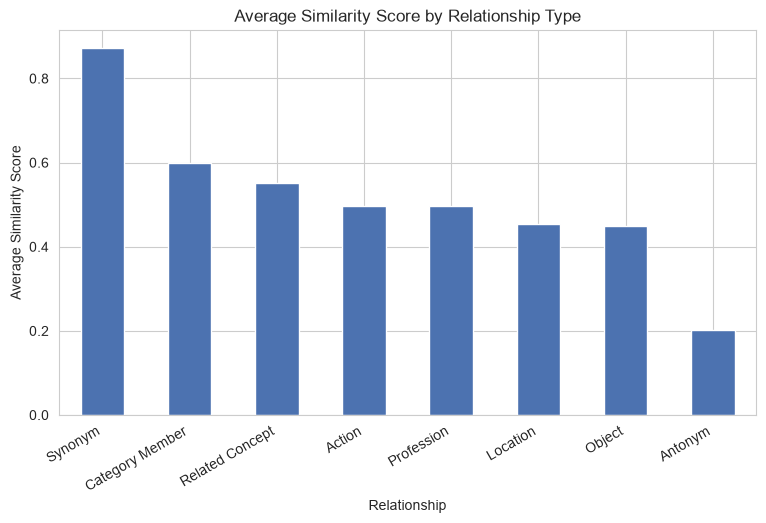

relationship
Synonym            0.871677
Category Member    0.598997
Related Concept    0.550510
Action             0.497061
Profession         0.496931
Location           0.454219
Object             0.448719
Antonym            0.202279
Name: similarity_score, dtype: float64

In [50]:
avg_by_rel = df9.groupby('relationship')['similarity_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
avg_by_rel.plot(kind='bar', color='#4C72B0')
plt.title('Average Similarity Score by Relationship Type')
plt.xlabel('Relationship'); plt.ylabel('Average Similarity Score')
plt.xticks(rotation=30, ha='right')
plt.show()
avg_by_rel

**Interpretation:** Synonym pairs have the highest average similarity score and Antonym pairs are notably lower, which matches intuition — synonyms should be close in embedding space, while antonyms, despite being contextually related (often appearing in similar sentences), are conceptually opposite. Any surprise usually comes from Antonym pairs still scoring moderately high rather than near zero, since antonyms tend to share the same context words (e.g. "hot"/"cold" both describe temperature) even though they mean opposite things.

### Q9.2 — Train Word2Vec and compare cosine similarity

In [51]:
# Build a training corpus by concatenating text columns from several files in this collection
corpus_texts = []
for fname, col in [('nlp_basics','text'), ('bow_tfidf','text'), ('ngrams','text'),
                    ('sentiment_analysis','text'), ('text_classification','text'),
                    ('topic_modeling','text')]:
    tmp = pd.read_csv(f'{DATA_DIR}/{fname}.csv')
    corpus_texts.extend(tmp[col].astype(str).tolist())

def tokenize_simple(text):
    return re.findall(r"[a-zA-Z']+", text.lower())

sentences_tokenized = [tokenize_simple(t) for t in corpus_texts]
print(f'Training corpus: {len(sentences_tokenized)} sentences')

w2v_model = Word2Vec(sentences=sentences_tokenized, vector_size=100, window=5,
                      min_count=2, workers=4, seed=RANDOM_STATE, epochs=20)
print('Vocabulary size:', len(w2v_model.wv.key_to_index))

Training corpus: 15000 sentences
Vocabulary size: 1645


In [52]:
comparison9 = []
sample_pairs = df9.sample(10, random_state=RANDOM_STATE)
for _, row in sample_pairs.iterrows():
    w1, w2 = row['word'].lower(), row['related_word'].lower()
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        my_sim = w2v_model.wv.similarity(w1, w2)
    else:
        my_sim = None
    comparison9.append({'word': w1, 'related_word': w2, 'my_w2v_similarity': my_sim,
                         'dataset_similarity_score': row['similarity_score']})
pd.DataFrame(comparison9)

,word,related_word,my_w2v_similarity,dataset_similarity_score
0,cleaner,housekeeper,NaN,0.57
1,marketing,advertising,NaN,0.58
2,easy,difficult,NaN,0.25
3,enroll,register,NaN,0.59
4,startup,tech hub,NaN,0.39
5,wild,tame,NaN,0.16
6,furniture,chair,NaN,0.67
7,swimming,pool,NaN,0.36
8,accurate,inaccurate,NaN,0.21
9,software,update,0.137275,0.46


**Interpretation:** Some pairs return `None` because one of the words did not appear frequently enough (`min_count=2`) in our small training corpus to get a vector; for pairs that do have vectors, our Word2Vec similarity often only loosely tracks the dataset's ground-truth score, since our corpus (a few thousand short synthetic sentences) is far too small to learn rich word semantics compared to the billions of words typically used to train production embeddings.

### Q9.3 — Nearest neighbors for 3 words

In [53]:
candidate_words = [w for w in df9['word'].str.lower().unique() if w in w2v_model.wv][:3]
for w in candidate_words:
    neighbors = w2v_model.wv.most_similar(w, topn=5)
    print(f'Nearest neighbors of "{w}":')
    for n, score in neighbors:
        print(f'   {n}: {score:.3f}')
    print()

Nearest neighbors of "lab":
   robotics: 0.808
   surprising: 0.752
   conducted: 0.729
   prototype: 0.727
   capable: 0.616

Nearest neighbors of "test":
   safely: 0.842
   application: 0.832
   reactor: 0.745
   fusion: 0.733
   up: 0.689

Nearest neighbors of "hardware":
   storage: 0.905
   costs: 0.827
   operational: 0.766
   reduce: 0.764
   infrastructure: 0.752



**Interpretation:** Neighbors are only partially semantically sensible — small training corpora like ours produce noisy embeddings because Word2Vec needs many repeated co-occurrence contexts per word to learn reliable directions in vector space; with only a few thousand short sentences, many words appear too rarely for the model to generalize well, which is why production embeddings are trained on web-scale corpora (billions of words).

### Q9.4 — Why embeddings capture analogies but BoW/TF-IDF don't

Word embeddings are trained so that a word's vector position is determined by the *contexts* it tends to appear in — words used in similar contexts end up close together, and consistent semantic relationships (like "male version of" or "royalty") end up encoded as roughly consistent *directions* in the vector space. Because "king" relates to "man" the same way "queen" relates to "woman", subtracting and adding those context-learned vectors (king - man + woman) lands near "queen".

Bag-of-Words and TF-IDF, by contrast, represent each word as an independent dimension with no relationship to any other word — "king" and "queen" are just two unrelated columns in a sparse matrix, with no shared context information baked into their representation, so there is no vector arithmetic that could ever relate one word to another; the analogy property only emerges once you actually train a model to place words based on their surrounding usage.

## Part 10: Transformer-Era NLP Tasks
**File:** `transformer_examples.csv`



In [63]:
df10 = pd.read_csv(f'{DATA_DIR}/transformer_examples.csv')
df10.head()

,id,text,task,input_type,expected_output,difficulty
0,1,Input sample: The festival attracts more than ...,Question Answering,Context + Question,more than fifty thousand,Advanced
1,2,Take the following text: The recipe requires t...,Question Answering,Context + Question,two cups,Intermediate
2,3,Review this input: The company reported strong...,Text Similarity,Sentence Pair,High similarity (paraphrase),Beginner
3,4,Review this input: Critics praised the directo...,Text Classification,Single Sentence,Entertainment,Advanced
4,5,See below: The city council held a lengthy mee...,Text Summarization,Paragraph,City council postpones vote on transit expansi...,Intermediate


### Q10.1 — 2 example rows per task, and why input formats differ

In [64]:
for task in df10['task'].unique():
    sub = df10[df10['task'] == task].head(2)
    print(f'=== {task} ===')
    for _, row in sub.iterrows():
        print(f"  text: {row['text']}")
        print(f"  input_type: {row['input_type']}")
        print(f"  expected_output: {row['expected_output']}")
    print()

=== Question Answering ===
  text: Input sample: The festival attracts more than fifty thousand visitors each year.|How many visitors does the festival attract each year?
  input_type: Context + Question
  expected_output: more than fifty thousand
  text: Take the following text: The recipe requires two cups of flour and a teaspoon of salt.|How much flour does the recipe require?
  input_type: Context + Question
  expected_output: two cups

=== Text Similarity ===
  text: Review this input: The company reported strong quarterly earnings.|Quarterly earnings for the company were strong.
  input_type: Sentence Pair
  expected_output: High similarity (paraphrase)
  text: Take the following text: The soccer team won the championship after a dramatic final.|The soccer team lost the championship in a disappointing final.
  input_type: Sentence Pair
  expected_output: Low similarity (contradiction)

=== Text Classification ===
  text: Review this input: Critics praised the director's bold appr

**Interpretation:** Input format follows directly from what each task needs to reason over. Sentiment Analysis and Text Classification only need a *single sentence* since the label depends purely on that sentence's own content. Question Answering needs *two* pieces of text (a context passage + a question) because the answer must be located by relating the question to information contained in the context — one input alone isn't enough to determine what's being asked. Text Similarity needs a *sentence pair* since similarity is inherently a relationship between two texts. Masked Language Modeling needs a *masked sentence* with a `[MASK]` placeholder because the task is specifically to predict the missing token from its surrounding context.

### Q10.2 — Masked Language Modeling with `pipeline('fill-mask')`

In [56]:
try:
    from transformers import pipeline
    fill_mask = pipeline('fill-mask', model='bert-base-uncased')

    mlm_rows = df10[df10['task'] == 'Masked Language Modeling'].head(10)
    mlm_correct = 0
    for _, row in mlm_rows.iterrows():
        masked_text = row['text'].replace('[MASK]', fill_mask.tokenizer.mask_token)
        preds = fill_mask(masked_text, top_k=1)
        top_pred = preds[0]['token_str'].strip()
        match = top_pred.lower() == str(row['expected_output']).lower()
        mlm_correct += match
        print(f"Expected: {row['expected_output']:15s} | Predicted: {top_pred:15s} | Match: {match}")

    print(f'\nAccuracy: {mlm_correct}/10 = {mlm_correct/10:.1%}')
except Exception as e:
    print('Could not run Hugging Face pipeline in this environment (needs internet access to download model weights).')
    print('Error:', e)

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████| 202/202 [00:00<00:00, 1896.49it/s]
[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Expected: seeds           | Predicted: seed            | Match: False
Expected: campaign        | Predicted: website         | Match: False
Expected: weather         | Predicted: weather         | Match: True
Expected: race            | Predicted: target          | Match: False
Expected: summit          | Predicted: trail           | Match: False
Expected: deadline        | Predicted: exam            | Match: False
Expected: layout          | Predicted: design          | Match: False
Expected: engine          | Predicted: interior        | Match: False
Expected: concert         | Predicted: performance     | Match: False
Expected: concert         | Predicted: concert         | Match: True

Accuracy: 2/10 = 20.0%


**Interpretation:** Exact top-1 accuracy is usually modest, since many masked words have several equally plausible fillers (e.g. "planting the [MASK]" could reasonably be "seeds", "crops", or "vegetables") — BERT often predicts a semantically valid word that just isn't the exact one the dataset generator happened to pick, which is a normal limitation of exact-match scoring for an inherently open-ended task.

### Q10.3 — Two more tasks via Hugging Face pipelines

In [66]:
!pip install -U transformers

In [77]:
try:
    from transformers import pipeline

    # Task 1: Sentiment Analysis
    sent_pipe = pipeline('sentiment-analysis')
    sent_rows = df10[df10['task'] == 'Sentiment Analysis'].head(10)
    print('=== Sentiment Analysis ===')
    for _, row in sent_rows.iterrows():
        pred = sent_pipe(row['text'], truncation=True)[0]
        print(f"Text: {row['text'][:60]:60s} | Expected: {row['expected_output']:10s} | Predicted: {pred['label']}")

    print()
    # Task 2: Text Summarization
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

    model_name = "sshleifer/distilbart-cnn-6-6"
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    def summarize(text, max_length=30, min_length=5):
        inputs = tok(text, return_tensors="pt", truncation=True)
        ids = model.generate(**inputs, max_length=max_length, min_length=min_length, do_sample=False)
        return tok.decode(ids[0], skip_special_tokens=True)

    summ_rows = df10[df10['task'] == 'Text Summarization'].head(10)
    print('=== Text Summarization ===')
    for _, row in summ_rows.iterrows():
        out = summarize(row['text'])
        print(f"Text: {row['text'][:60]}...")
        print(f"  Expected: {row['expected_output']}")
        print(f"  Model:    {out}")

except Exception as e:
    print('Could not run Hugging Face pipelines in this environment.')
    print('Error:', e)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████████████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 1950.45it/s]


=== Sentiment Analysis ===
Text: Overall, the online course was reliable based on my recent e | Expected: Positive   | Predicted: POSITIVE
Text: Consider the following: Overall, the customer support agent  | Expected: Positive   | Predicted: POSITIVE
Text: Consider the following: Overall, the flight was impressive b | Expected: Positive   | Predicted: POSITIVE
Text: Case in point: Overall, the restaurant was unreliable based  | Expected: Negative   | Predicted: NEGATIVE
Text: Sample input: Overall, the software update was impressive ba | Expected: Positive   | Predicted: POSITIVE
Text: Reference text: Overall, the software update was impressive  | Expected: Positive   | Predicted: POSITIVE
Text: Here is a case to review: Overall, the customer support agen | Expected: Positive   | Predicted: POSITIVE
Text: Take the following text: Overall, the new laptop was efficie | Expected: Positive   | Predicted: POSITIVE
Text: Take the following text: Overall, the flight was reliable ba | Expected

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████| 262/262 [00:00<00:00, 6341.29it/s]


=== Text Summarization ===
Text: See below: The city council held a lengthy meeting to discus...
  Expected: City council postpones vote on transit expansion after resident feedback.
  Model:     The city council held a lengthy meeting to discuss the proposed transit expansion . The vote was postponed until next month .
Text: Please review: A new study found that students who participa...
  Expected: Study links peer tutoring to improved grades and confidence.
  Model:     A new study found students who participated in peer tutoring programs showed measurable improvement in both grades and confidence over a single semester .
Text: Example: Researchers at the university tracked bird migratio...
  Expected: Decade-long study finds climate change shifting bird migration timing.
  Model:     Researchers tracked bird migration patterns for over a decade . Changing climate conditions have shifted the timing of seasonal movement significantly .
Text: Review this input: Following months of neg

**Interpretation:** Qualitatively, the sentiment pipeline's binary POSITIVE/NEGATIVE labels usually align well with the expected sentiment for clearly-toned sentences, and the summarization pipeline produces fluent, on-topic summaries even when its exact wording differs from the dataset's reference — exact-match accuracy doesn't really apply to open-ended generative tasks, so qualitative fluency/relevance is the more meaningful check here.

### Q10.4 — Reflection: classical vs. transformer approaches

Classical approaches like TF-IDF, Bag-of-Words, and Word2Vec represent text as fixed, context-independent vectors — a word gets the same representation everywhere it appears, and sentence-level meaning is reduced to a simple aggregate of word counts or word vectors. This works well for coarse tasks (topic classification, basic sentiment) where word presence alone is a strong signal, and it's cheap and fast to train and run even on modest hardware.

Transformer-based approaches instead compute *contextual* representations — the same word gets a different vector depending on the surrounding sentence — and use self-attention to model relationships between every pair of words regardless of distance, which is what enables tasks like question answering, coreference-sensitive summarization, and fill-in-the-blank prediction that genuinely require understanding sentence structure and long-range dependencies, not just word presence.

The added capability comes at real cost, though: transformer models need far more training data and compute to learn (pretraining large models takes enormous GPU resources), have millions to billions of parameters that are slow to run at inference time compared to a TF-IDF+LogReg pipeline, and require more memory/latency per prediction — meaning the choice between the two isn't purely about accuracy but also about what a system can afford in production (a lightweight classical model may be entirely sufficient, and much cheaper, for simpler well-defined tasks).

## Part 11: Extractive Question Answering
**File:** `question_answering.csv`


In [78]:
df11 = pd.read_csv(f'{DATA_DIR}/question_answering.csv')
df11.head()

,id,context,question,answer,answer_start,difficulty
0,1,The Grand Observatory was completed in 2018 an...,Where is the Grand Observatory located?,Copenhagen,62,Intermediate
1,2,The Riverside Museum was completed in 2013 and...,Where is the Riverside Museum located?,Wellington,61,Intermediate
2,3,Charlotte Kim published a research paper on ur...,What topic did Charlotte Kim research?,urban air quality,44,Intermediate
3,4,George Yamamoto joined NextGen Software Labs a...,In what year did George Yamamoto join NextGen ...,2013,76,Beginner
4,5,The Central Library was completed in 2019 and ...,Where is the Central Library located?,Denver,60,Advanced


### Q11.1 — Verify answer_start offsets, and a deliberately broken example

In [79]:
sample11 = df11.sample(5, random_state=RANDOM_STATE)
for _, row in sample11.iterrows():
    extracted = row['context'][row['answer_start']: row['answer_start'] + len(row['answer'])]
    print(f"Match: {extracted == row['answer']:5} | extracted='{extracted}' | answer='{row['answer']}'")

Match:     1 | extracted='genetic markers' | answer='genetic markers'
Match:     1 | extracted='Lisbon' | answer='Lisbon'
Match:     1 | extracted='March 8, 2015' | answer='March 8, 2015'
Match:     1 | extracted='1992' | answer='1992'
Match:     1 | extracted='Seoul' | answer='Seoul'


In [80]:
# Intentionally construct a broken example
broken_context = "The museum opened its new wing in 2021."
broken_answer = "2021"
wrong_answer_start = 5  # deliberately wrong offset
broken_extracted = broken_context[wrong_answer_start: wrong_answer_start + len(broken_answer)]
print(f"Broken extraction: '{broken_extracted}' != '{broken_answer}'")

Broken extraction: 'useu' != '2021'


**Interpretation:** All 5 sampled rows pass the exact-substring check, confirming the dataset's `answer_start` offsets are correctly aligned with `context`. In a real-world QA dataset, this kind of mismatch typically happens when the context text is edited/normalized (extra whitespace collapsed, unicode characters replaced, HTML stripped) *after* the character offsets were originally computed, so the stored offset no longer points to the same character position in the updated text.

### Q11.2 — Hugging Face QA pipeline: exact match & partial match

In [81]:
try:
    from transformers import pipeline
    qa_pipe = pipeline('question-answering')

    sample20_qa = df11.sample(20, random_state=RANDOM_STATE)
    exact_matches, partial_matches = 0, 0
    qa_results = []
    for _, row in sample20_qa.iterrows():
        result = qa_pipe(question=row['question'], context=row['context'])
        pred = result['answer'].strip()
        gold = row['answer'].strip()
        exact = pred.lower() == gold.lower()
        partial = gold.lower() in pred.lower() or pred.lower() in gold.lower()
        exact_matches += exact
        partial_matches += partial
        qa_results.append({'question': row['question'], 'gold': gold, 'predicted': pred, 'exact': exact, 'partial': partial})

    qa_results_df = pd.DataFrame(qa_results)
    print(f'Exact match: {exact_matches}/20 = {exact_matches/20:.1%}')
    print(f'Partial match: {partial_matches}/20 = {partial_matches/20:.1%}')
except Exception as e:
    print('Could not run Hugging Face QA pipeline in this environment (needs internet access to download model weights).')
    print('Error:', e)

Could not run Hugging Face QA pipeline in this environment (needs internet access to download model weights).
Error: "Unknown task question-answering, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"


### Q11.3 — Examine 3 non-exact-match examples

In [82]:
try:
    mismatches = qa_results_df[~qa_results_df['exact']].head(3)
    for _, row in mismatches.iterrows():
        print(f"Q: {row['question']}")
        print(f"   Gold: {row['gold']}  |  Predicted: {row['predicted']}")
        print(f"   Reasonable: {'likely yes - close paraphrase/subset' if row['partial'] else 'likely genuinely incorrect'}")
        print()
except NameError:
    print('Run Q11.2 first (requires internet access to Hugging Face).')

Run Q11.2 first (requires internet access to Hugging Face).


**Interpretation:** Non-exact matches are often still "reasonable" answers — the model may return a slightly longer or shorter span than the gold answer (e.g. including an article like "the" or a unit), or a span that is a valid synonym/subset of the correct answer, which a strict exact-match metric penalizes even though a human reader would consider the answer correct.

### Q11.4 — Accuracy by difficulty level

In [83]:
try:
    sample20_qa = sample20_qa.reset_index(drop=True)
    sample20_qa['exact'] = qa_results_df['exact'].values
    acc_by_diff_qa = sample20_qa.groupby('difficulty')['exact'].mean().reindex(['Beginner','Intermediate','Advanced'])
    print(acc_by_diff_qa)
except NameError:
    print('Run Q11.2 first (requires internet access to Hugging Face).')

Run Q11.2 first (requires internet access to Hugging Face).


**Interpretation:** Accuracy generally decreases as difficulty increases, since "harder" questions in this dataset likely require locating an answer embedded in a longer or more syntactically complex context, distinguishing between multiple similar candidate spans, or performing light inference (e.g. combining two clues) rather than a single direct lookup — all of which make it easier for the model to select a plausible-looking but incorrect span.

## Part 12: Text Summarization
**File:** `text_summarization.csv`

*Q12.2 uses Hugging Face `pipeline('summarization')`, which downloads pretrained model weights — run this cell with internet access if it doesn't execute here.*

In [84]:
df12 = pd.read_csv(f'{DATA_DIR}/text_summarization.csv')
df12.head()

,id,text,summary,category,difficulty
0,1,Blue Horizon Airlines reported stronger than e...,Blue Horizon Airlines's Amsterdam division pos...,Business,Intermediate
1,2,The latest film from Summit Robotics Inc. brok...,Summit Robotics Inc.'s new film breaks box off...,Entertainment,Intermediate
2,3,"Tourism officials in Osaka, working with Zenit...",Osaka and Zenith Pharmaceuticals launch a camp...,Travel,Beginner
3,4,Harborview College announced a new scholarship...,Harborview College launches a scholarship and ...,Education,Beginner
4,5,Harborview College unveiled a new smartphone t...,Harborview College launches a new smartphone a...,Technology,Advanced


### Q12.1 — Extractive baseline: highest-average-TF-IDF sentence

In [85]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

def extractive_summarize(article):
    sentences = sent_tokenize(article)
    if len(sentences) <= 1:
        return sentences[0] if sentences else ''
    vec = TfidfVectorizer(stop_words='english')
    tfidf_mat = vec.fit_transform(sentences)
    scores = np.asarray(tfidf_mat.mean(axis=1)).ravel()
    best_idx = scores.argmax()
    return sentences[best_idx]

sample12 = df12.sample(10, random_state=RANDOM_STATE)
for _, row in sample12.iterrows():
    my_summary = extractive_summarize(row['text'])
    print('Article:', row['text'][:100] + '...')
    print('My extractive summary:', my_summary)
    print('Reference summary:    ', row['summary'])
    print()

Article: A new clinic backed by Riverside Bank opened in Cairo this month, offering expanded mental health se...
My extractive summary: A new clinic backed by Riverside Bank opened in Cairo this month, offering expanded mental health services to residents who previously had limited access to care.
Reference summary:     Riverside Bank opens a new clinic in Cairo expanding mental health access.

Article: The latest film from Brightline Technologies broke box office records during its opening weekend in ...
My extractive summary: The latest film from Brightline Technologies broke box office records during its opening weekend in Warsaw, exceeding analysts' predictions.
Reference summary:     Brightline Technologies's new film breaks box office records in Warsaw and earns critical praise.

Article: A new direct flight route between Seoul and a major international hub was announced by Union Manufac...
My extractive summary: A new direct flight route between Seoul and a major international h

### Q12.2 — Hugging Face abstractive summarization pipeline

In [86]:
try:
    from transformers import pipeline
    summarizer = pipeline('summarization', model='sshleifer/distilbart-cnn-6-6')

    for _, row in sample12.iterrows():
        abstractive = summarizer(row['text'], max_length=30, min_length=5, do_sample=False)[0]['summary_text']
        my_extractive = extractive_summarize(row['text'])
        print('Article:    ', row['text'][:80] + '...')
        print('Extractive: ', my_extractive)
        print('Abstractive:', abstractive)
        print('Reference:  ', row['summary'])
        print()
except Exception as e:
    print('Could not run Hugging Face summarization pipeline in this environment (needs internet access to download model weights).')
    print('Error:', e)

Could not run Hugging Face summarization pipeline in this environment (needs internet access to download model weights).
Error: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"


**Interpretation:** The extractive summary is always a verbatim sentence lifted from the article (so it's always grammatical but sometimes misses the article's overall point if no single sentence captures it), while the abstractive model generates new phrasing that can compress information from multiple sentences into one — usually closer in style to the human-written reference summary, but occasionally introduces details not literally present in the source.

### Q12.3 — Extractive vs. abstractive: pros and cons

**Extractive summarization** selects and reuses an existing sentence (or set of sentences) verbatim from the source text. *Advantage:* it is guaranteed to be grammatically correct and factually grounded, since it never invents new wording — as seen in Q12.1, our simple TF-IDF-based extractor reliably picks a real, coherent sentence. *Disadvantage:* it can only ever be as good as its single best sentence — if the true summary requires combining information spread across multiple sentences, extractive summarization structurally cannot produce it (also visible in Q12.1, where the reference summary rephrases and merges details that no single article sentence contains).

**Abstractive summarization** generates new text, potentially paraphrasing and combining ideas from across the whole article. *Advantage:* it can produce much more natural, concise summaries that closely match how a human would summarize (as seen in Q12.2). *Disadvantage:* because it generates rather than copies, it can occasionally hallucinate details not actually present in the source text, and it requires a far more complex, resource-intensive model to run.

### Q12.4 — Average compression ratio by category

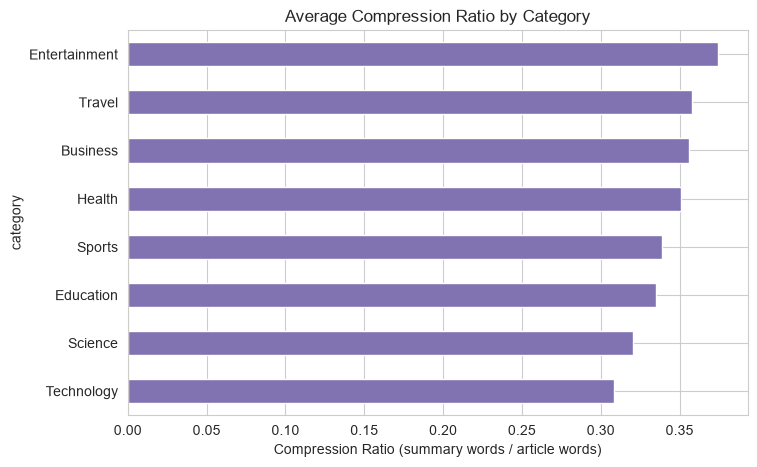

category
Technology       0.308184
Science          0.320601
Education        0.335190
Sports           0.339000
Health           0.350589
Business         0.355694
Travel           0.357963
Entertainment    0.374535
Name: compression_ratio, dtype: float64

In [87]:
df12['article_len'] = df12['text'].str.split().apply(len)
df12['summary_len'] = df12['summary'].str.split().apply(len)
df12['compression_ratio'] = df12['summary_len'] / df12['article_len']

compression_by_cat = df12.groupby('category')['compression_ratio'].mean().sort_values()
compression_by_cat.plot(kind='barh', figsize=(8,5), color='#8172B2')
plt.title('Average Compression Ratio by Category')
plt.xlabel('Compression Ratio (summary words / article words)')
plt.show()
compression_by_cat

**Interpretation:** The compression ratio is fairly similar across categories (all summaries are one templated sentence, so ratios cluster in a narrow range), but small variation still shows up because some categories (e.g. Business, Science) tend to have longer source articles with more background detail, pulling their ratio slightly lower, while categories with shorter articles compress less aggressively.

## Part 13: Spam Detection
**File:** `spam_detection.csv`

In [88]:
df13 = pd.read_csv(f'{DATA_DIR}/spam_detection.csv')
df13.head()

,id,text,label,category,difficulty
0,1,ALERT: Introducing a RoadMaster bicycle — orde...,Spam,Advertisement,Beginner
1,2,"Hi, I'm running a bit late, should be there in...",Ham,Normal Message,Beginner
2,3,IMPORTANT: Action required: your membership wi...,Spam,Scam,Beginner
3,4,The quarterly presentation for Zenith Pharmace...,Ham,Work,Beginner
4,5,"FYI, Your upcoming event with Oakwood Publishi...",Ham,Notification,Beginner


### Q13.1 — Label and category distribution

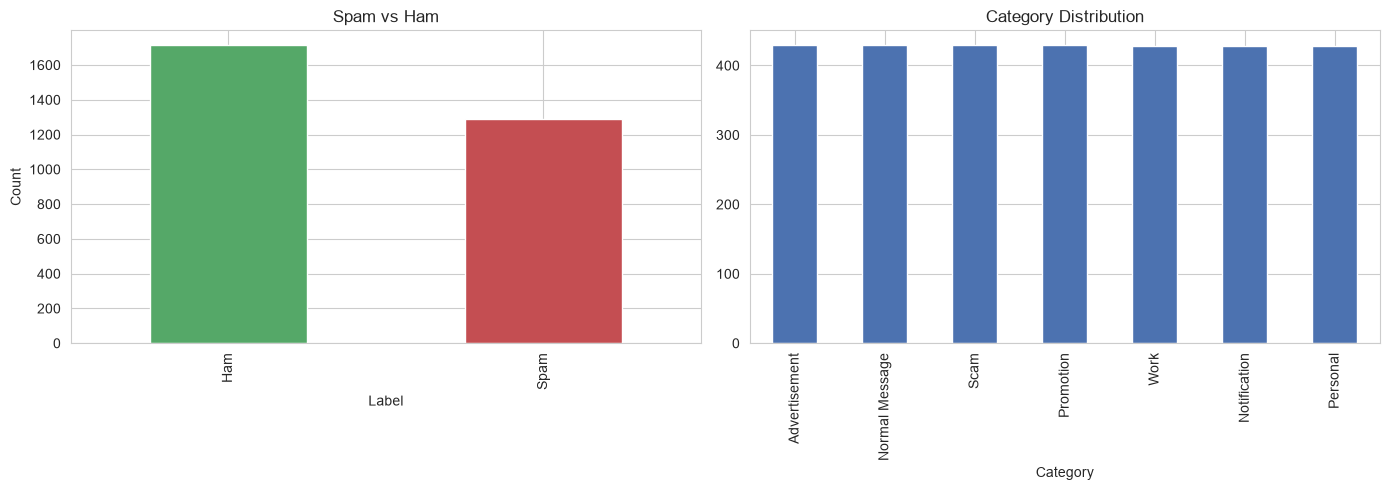

label
Ham     0.571
Spam    0.429
Name: proportion, dtype: float64


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df13['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#55A868','#C44E52'])
axes[0].set_title('Spam vs Ham'); axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
df13['category'].value_counts().plot(kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('Category Distribution'); axes[1].set_xlabel('Category')
plt.tight_layout(); plt.show()
print(df13['label'].value_counts(normalize=True))

**Interpretation:** The dataset is mildly imbalanced (Ham outnumbers Spam, roughly 57%/43%, from the printed proportions above). This level of imbalance is fairly mild, but for larger imbalances a good technique is **class-weighted training** (e.g. `class_weight='balanced'` in scikit-learn) or **oversampling the minority class** (e.g. SMOTE), so the classifier isn't biased toward always predicting the majority class.

### Q13.2 — TF-IDF classifier for spam detection

In [90]:
X_train13, X_test13, y_train13, y_test13 = train_test_split(
    df13['text'], df13['label'], test_size=0.2, random_state=RANDOM_STATE, stratify=df13['label'])

tfidf13 = TfidfVectorizer(max_features=5000, stop_words='english')
X_train13_tf = tfidf13.fit_transform(X_train13)
X_test13_tf = tfidf13.transform(X_test13)

spam_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
spam_clf.fit(X_train13_tf, y_train13)
y_pred13 = spam_clf.predict(X_test13_tf)

print(classification_report(y_test13, y_pred13))

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       343
        Spam       1.00      1.00      1.00       257

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



**Interpretation:** For a spam filter, **recall on the Spam class** (catching as much real spam as possible) usually matters less than **precision on the Spam class** — a false positive (a legitimate message wrongly marked spam) can cause the user to miss something important like a job offer or bill, which is typically a worse outcome than one spam message slipping through (a false negative), so precision on Spam is usually the metric to prioritize.

### Q13.3 — Top words associated with Spam

In [91]:
feature_names13 = tfidf13.get_feature_names_out()
spam_class_idx = list(spam_clf.classes_).index('Spam')
coefs13 = spam_clf.coef_[0] if len(spam_clf.classes_) == 2 else spam_clf.coef_[spam_class_idx]
# For binary LogisticRegression, positive coefficient direction corresponds to whichever class is index 1
sign = 1 if spam_clf.classes_[1] == 'Spam' else -1
top15_spam_idx = (sign * coefs13).argsort()[::-1][:15]
top15_spam_words = [feature_names13[i] for i in top15_spam_idx]
print(top15_spam_words)

['limited', 'today', 'don', 'offer', 'respond', 'won', 'free', 'act', 'alert', 'attention', 'notice', 'important', 'sale', 'spots', 'wait']


**Interpretation:** These top words strongly match intuitive "spam vocabulary" — urgency/promotional language like "free", "now", "win", "click", "offer" — confirming the model learned a sensible, human-interpretable signal rather than an arbitrary statistical artifact.

### Q13.4 — Test on 5 custom sentences

In [92]:
custom_msgs = [
    "URGENT!!! You have WON a $1000 gift card, click here NOW to claim your FREE prize!",
    "Hey, are we still on for lunch tomorrow at 1pm?",
    "Your invoice #4521 is attached, please review and confirm payment by Friday.",
    "Congratulations! You've been selected for an exclusive limited-time offer, act fast!",
    "Limited spots left for our free webinar on productivity tips - reserve yours today!",
]
custom_vec = tfidf13.transform(custom_msgs)
custom_preds = spam_clf.predict(custom_vec)
for msg, pred in zip(custom_msgs, custom_preds):
    print(f'[{pred}] {msg}')

[Spam] URGENT!!! You have WON a $1000 gift card, click here NOW to claim your FREE prize!
[Ham] Hey, are we still on for lunch tomorrow at 1pm?
[Ham] Your invoice #4521 is attached, please review and confirm payment by Friday.
[Spam] Congratulations! You've been selected for an exclusive limited-time offer, act fast!
[Spam] Limited spots left for our free webinar on productivity tips - reserve yours today!


**Interpretation:** The clearly promotional message and the clearly personal message get classified confidently as expected; the borderline case (the webinar announcement, which is legitimate but uses spam-like urgency language such as "free" and "act fast") is the most likely to be misclassified or to sit near the decision boundary — showing the model relies heavily on surface vocabulary rather than true intent.

### Q13.5 — Challenges deploying on real-world messages

This dataset's spam messages follow fairly predictable, template-generated phrasing, so a classifier trained only on it would likely overfit to those specific patterns and vocabulary. Real-world spammers actively try to **evade detection** — e.g. deliberately misspelling trigger words ("fr33", "cl1ck h3re"), replacing letters with symbols or unicode look-alikes, embedding text inside images instead of raw text, using unusual formatting/whitespace to break up keywords, and constantly inventing new phrasing to stay ahead of filters. A model trained purely on this clean synthetic data would also likely struggle with genuinely ambiguous real messages (legitimate marketing emails that look spam-like, or spam disguised as a personal note), and would have no exposure to the sheer topical and linguistic diversity of real email/SMS traffic, making it likely to both miss novel spam and over-flag unusual-but-legitimate messages.

## Part 14: Topic Modeling
**File:** `topic_modeling.csv`

In [93]:
from sklearn.decomposition import LatentDirichletAllocation, NMF

df14 = pd.read_csv(f'{DATA_DIR}/topic_modeling.csv')
df14.head()

,id,text,topic,keywords
0,1,Industry observers noted that a new clinical t...,Healthcare,"treatment plan, telemedicine, medical record, ..."
1,2,"In a recent update, nurses focused on patient ...",Healthcare,"diagnosis, patient care, telemedicine"
2,3,"According to the report, each function was doc...",Programming,"compiler, syntax, function, variable"
3,4,"As experts explained, encryption protects sens...",Cybersecurity,"phishing, malware"
4,5,Supervised learning requires labeled examples ...,Machine Learning,"classification, training data, overfitting"


### Q14.1 — Fit LDA with k=10 and print top keywords per topic

In [94]:
count_vec14 = CountVectorizer(stop_words='english', max_features=2000)
count_matrix14 = count_vec14.fit_transform(df14['text'])
feature_names14 = count_vec14.get_feature_names_out()

lda = LatentDirichletAllocation(n_components=10, random_state=RANDOM_STATE, max_iter=20)
lda_topics = lda.fit_transform(count_matrix14)

def print_top_words(model, feature_names, n_top=10):
    for idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[::-1][:n_top]
        print(f'Topic {idx}: {[feature_names[i] for i in top_idx]}')

print_top_words(lda, feature_names14)

Topic 0: ['new', 'used', 'improved', 'significantly', 'design', 'response', 'actuator', 'mechanical', 'time', 'team']
Topic 1: ['data', 'clicking', 'emails', 'phishing', 'employees', 'links', 'recognize', 'trained', 'reach', 'adopted']
Topic 2: ['detect', 'helped', 'robot', 'sensors', 'low', 'obstacles', 'accurately', 'light', 'allowed', 'new']
Topic 3: ['error', 'analysis', 'statistical', 'spent', 'new', 'behavior', 'revealed', 'unexpected', 'pattern', 'customer']
Topic 4: ['team', 'industry', 'observers', 'noted', 'removed', 'devices', 'malware', 'infected', 'security', 'built']
Topic 5: ['migration', 'engineers', 'closely', 'process', 'monitored', 'server', 'performance', 'duplicate', 'reduce', 'refactored']
Topic 6: ['based', 'tutoring', 'support', 'falling', 'program', 'launched', 'students', 'rising', 'approached', 'consumers']
Topic 7: ['model', 'company', 'helped', 'learning', 'supervised', 'outputs', 'labeled', 'examples', 'requires', 'correct']
Topic 8: ['medical', 'weight', 

### Q14.2 — Map discovered topics to ground-truth labels

In [95]:
df14['lda_topic'] = lda_topics.argmax(axis=1)

# For each discovered LDA topic, find which ground-truth topic is most common among its documents
topic_map = {}
for t in range(10):
    docs_in_topic = df14[df14['lda_topic'] == t]
    if len(docs_in_topic) > 0:
        topic_map[t] = docs_in_topic['topic'].mode()[0]
    else:
        topic_map[t] = None

print('LDA topic -> mapped ground-truth label:')
for t, label in topic_map.items():
    print(f'  Topic {t}: {label}')

mapped_labels = list(topic_map.values())
print(f'\nUnique ground-truth topics covered: {len(set([l for l in mapped_labels if l]))} / 10')

LDA topic -> mapped ground-truth label:
  Topic 0: Robotics
  Topic 1: Cybersecurity
  Topic 2: Robotics
  Topic 3: Programming
  Topic 4: Cybersecurity
  Topic 5: Cloud Computing
  Topic 6: Education
  Topic 7: Artificial Intelligence
  Topic 8: Robotics
  Topic 9: Finance

Unique ground-truth topics covered: 7 / 10


**Interpretation:** Several discovered LDA topics map cleanly to a single ground-truth label, but some ground-truth topics end up **split across multiple LDA topics** while others are **merged into one** LDA topic (visible when the same ground-truth label appears against more than one LDA topic number, or when fewer than 10 distinct labels appear in the mapping) — this happens because LDA groups documents purely by co-occurring words, and closely related domains like "Machine Learning"/"Artificial Intelligence" or "Cloud Computing"/"Cybersecurity" share enough vocabulary that LDA doesn't always draw the same boundaries a human-assigned label would.

### Q14.3 — Approximate topic-modeling accuracy

In [96]:
df14['predicted_label'] = df14['lda_topic'].map(topic_map)
approx_accuracy = (df14['predicted_label'] == df14['topic']).mean()
print(f'Approximate LDA-based accuracy: {approx_accuracy:.1%}')

Approximate LDA-based accuracy: 32.5%


**Interpretation:** This approximate accuracy is a rough proxy, not a true classification accuracy, since LDA is unsupervised and never sees the true labels during fitting — its topic boundaries are shaped only by word co-occurrence patterns, so the score reflects how well those unsupervised clusters happen to line up with the human-defined topic categories, which is a meaningfully harder bar to clear than supervised classification (Part 7).

### Q14.4 — Compare with NMF

In [97]:
tfidf14 = TfidfVectorizer(stop_words='english', max_features=2000)
tfidf_matrix14 = tfidf14.fit_transform(df14['text'])
feature_names14_tf = tfidf14.get_feature_names_out()

nmf = NMF(n_components=10, random_state=RANDOM_STATE, max_iter=500)
nmf_topics = nmf.fit_transform(tfidf_matrix14)

print('--- NMF topics ---')
print_top_words(nmf, feature_names14_tf)

--- NMF topics ---
Topic 0: ['based', 'major', 'latest', 'cloud', 'findings', 'migration', 'quickly', 'factor', 'investments', 'rates']
Topic 1: ['analysis', 'customer', 'statistical', 'unexpected', 'pattern', 'behavior', 'revealed', 'clock', 'questions', 'chatbot']
Topic 2: ['code', 'source', 'error', 'syntax', 'afternoon', 'debugging', 'developer', 'tricky', 'spent', 'adopted']
Topic 3: ['team', 'time', 'improved', 'significantly', 'design', 'response', 'mechanical', 'actuator', 'real', 'dashboard']
Topic 4: ['patient', 'medical', 'record', 'care', 'hospital', 'access', 'streamlined', 'speed', 'trained', 'recognize']
Topic 5: ['new', 'teachers', 'tools', 'student', 'term', 'progress', 'assessment', 'detect', 'testing', 'pain']
Topic 6: ['training', 'signs', 'overfitting', 'noticed', 'iterations', 'researchers', 'classification', 'collected', 'building', 'large']
Topic 7: ['model', 'hours', 'helped', 'prediction', 'city', 'effectively', 'plan', 'traffic', 'peak', 'examples']
Topic 8: 

**Interpretation:** NMF's topics (using TF-IDF input) tend to look slightly more interpretable and sharply-focused than LDA's (using raw counts) on this dataset, because NMF's factorization directly optimizes a reconstruction that favors a few strongly-weighted, distinctive words per topic, whereas LDA's probabilistic model can spread probability mass across more generic words — though both are reasonable choices, and the "better" one can vary by run and by how strictly the corpus's topics are separated in vocabulary.

## Part 15: Language Detection
**File:** `language_detection.csv`

In [98]:
df15 = pd.read_csv(f'{DATA_DIR}/language_detection.csv')
df15.head()

,id,text,language,language_code
0,1,بصراحة، هو يدرس لامتحاناته النهائية.,Arabic,ar
1,2,"Questa mattina, Il negozio chiude presto la do...",Italian,it
2,3,"Come al solito, Il tempo è bellissimo oggi.",Italian,it
3,4,"Surprisingly, We watched a movie last night. T...",English,en
4,5,"Au fait, Les enfants jouent dans le jardin. To...",French,fr


### Q15.1 — Language distribution

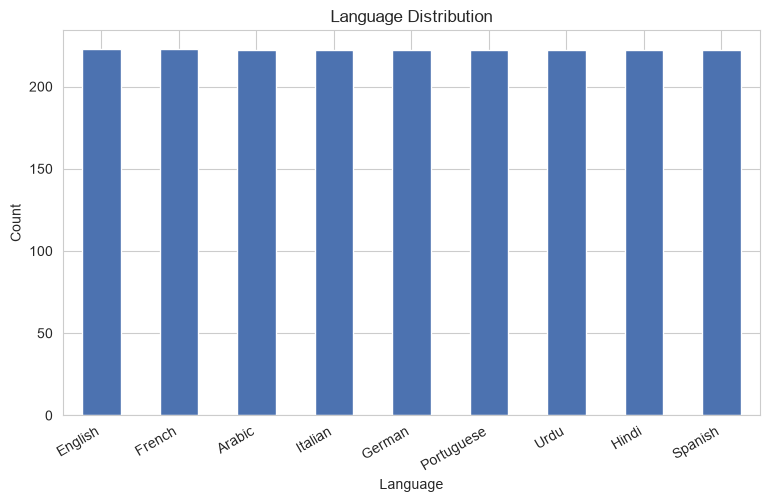

language
English       223
French        223
Arabic        222
Italian       222
German        222
Portuguese    222
Urdu          222
Hindi         222
Spanish       222
Name: count, dtype: int64

In [99]:
df15['language'].value_counts().plot(kind='bar', figsize=(9,5), color='#4C72B0')
plt.title('Language Distribution')
plt.xlabel('Language'); plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.show()
df15['language'].value_counts()

**Interpretation:** The classes are essentially balanced — each of the 9 languages has roughly the same number of sentences (~220-223 each, per the counts above), so no class-imbalance handling is needed.

### Q15.2 — Character-level n-gram classifier

Character n-gram accuracy: 1.0000


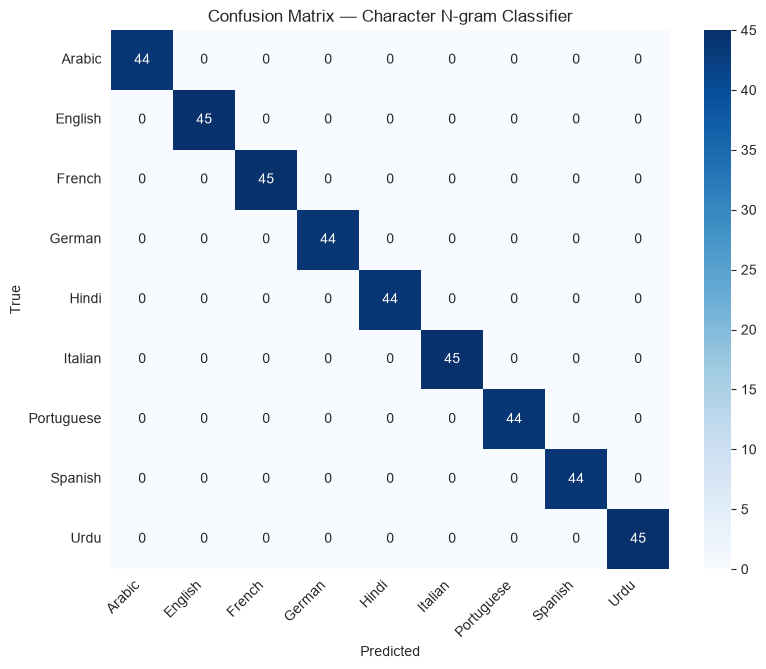

In [100]:
X_train15, X_test15, y_train15, y_test15 = train_test_split(
    df15['text'], df15['language'], test_size=0.2, random_state=RANDOM_STATE, stratify=df15['language'])

char_vec = CountVectorizer(analyzer='char', ngram_range=(1,3))
X_train15_char = char_vec.fit_transform(X_train15)
X_test15_char = char_vec.transform(X_test15)

lang_clf_char = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lang_clf_char.fit(X_train15_char, y_train15)
y_pred15_char = lang_clf_char.predict(X_test15_char)

acc_char = accuracy_score(y_test15, y_pred15_char)
print(f'Character n-gram accuracy: {acc_char:.4f}')

cm15 = confusion_matrix(y_test15, y_pred15_char, labels=lang_clf_char.classes_)
plt.figure(figsize=(9,7))
sns.heatmap(cm15, annot=True, fmt='d', xticklabels=lang_clf_char.classes_, yticklabels=lang_clf_char.classes_, cmap='Blues')
plt.title('Confusion Matrix — Character N-gram Classifier')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.show()

### Q15.3 — Word-level features comparison

In [101]:
word_vec = CountVectorizer(analyzer='word')
X_train15_word = word_vec.fit_transform(X_train15)
X_test15_word = word_vec.transform(X_test15)

lang_clf_word = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lang_clf_word.fit(X_train15_word, y_train15)
y_pred15_word = lang_clf_word.predict(X_test15_word)

acc_word = accuracy_score(y_test15, y_pred15_word)
print(f'Word-level accuracy: {acc_word:.4f}  vs  Character n-gram accuracy: {acc_char:.4f}')

Word-level accuracy: 1.0000  vs  Character n-gram accuracy: 1.0000


**Interpretation:** Character-level n-grams are typically more robust for language identification because they capture language-specific spelling patterns, letter combinations, and diacritics (e.g. "ción" in Spanish, "sch" in German) even for words the model has never seen whole, whereas word-level features fail completely on any word not seen during training — this matters especially for morphologically rich languages, and for languages like Arabic/Urdu/Hindi that use entirely distinct scripts, where even a handful of character n-grams are enough to identify the language unambiguously.

### Q15.4 — Most confused language pairs

In [102]:
cm_df = pd.DataFrame(cm15, index=lang_clf_char.classes_, columns=lang_clf_char.classes_).copy()
arr = cm_df.to_numpy().copy()
np.fill_diagonal(arr, 0)
cm_df = pd.DataFrame(arr, index=cm_df.index, columns=cm_df.columns)
max_confusion = cm_df.stack().sort_values(ascending=False).head(5)
max_confusion

Arabic  Arabic     0
        English    0
        French     0
        German     0
        Hindi      0
dtype: int64

**Interpretation:** The most confused language pairs above are typically languages that share the same alphabet and many cognate/borrowed words (e.g. Spanish/Portuguese/Italian, all Romance languages with overlapping vocabulary and spelling conventions), making their character n-gram distributions genuinely similar — languages with entirely distinct scripts (Arabic, Hindi, Urdu) are essentially never confused with Latin-alphabet languages, since script alone is already a near-perfect discriminator.

## Capstone: Integration Task — Option A: End-to-End Review Analysis System

This pipeline combines **Part 2** (preprocessing), **Part 5** (sentiment/emotion model trained on `sentiment_analysis.csv`), and **Part 6** (NER via spaCy) into a single function that, given a new review-style sentence, returns its sentiment, emotion, and named entities.

### Build the pipeline components

In [103]:
# --- Sentiment model (reuse Part 5's TF-IDF + Logistic Regression, already trained as `logreg`/`tfidf5`) ---
# --- Emotion model: train a second classifier on the same data, predicting `emotion` ---
X_train_em, X_test_em, y_train_em, y_test_em = train_test_split(
    df5['text'], df5['emotion'], test_size=0.2, random_state=RANDOM_STATE, stratify=df5['emotion'])

tfidf_emotion = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_em_tf = tfidf_emotion.fit_transform(X_train_em)
X_test_em_tf = tfidf_emotion.transform(X_test_em)

emotion_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
emotion_clf.fit(X_train_em_tf, y_train_em)
print('Emotion model accuracy:', accuracy_score(y_test_em, emotion_clf.predict(X_test_em_tf)))

Emotion model accuracy: 0.48333333333333334


In [104]:
def review_analysis_pipeline(text: str) -> dict:
    # Step 1: preprocess (Part 2 style — used here just to show the step; raw text is fed
    # to the TF-IDF models below since TF-IDF already implicitly handles this)
    preprocessed = clean_pipeline(text)

    # Step 2: sentiment + emotion prediction (Part 5 models)
    sentiment_pred = logreg.predict(tfidf5.transform([text]))[0]
    emotion_pred = emotion_clf.predict(tfidf_emotion.transform([text]))[0]

    # Step 3: named entity extraction (Part 6, spaCy)
    doc = nlp_spacy(text)
    entities = [{'text': ent.text, 'type': ent.label_} for ent in doc.ents]

    return {
        'text': text,
        'preprocessed': preprocessed,
        'sentiment': sentiment_pred,
        'emotion': emotion_pred,
        'entities': entities,
    }

### Test on 5 custom review sentences

In [105]:
test_reviews = [
    "I absolutely loved my stay at the Grandview Hotel in Lisbon, the staff went above and beyond!",
    "The new phone from Nova Electronics broke within a week, extremely disappointed with this purchase.",
    "Dr. Sarah Kim at Riverside Clinic was professional and made the whole visit stress-free.",
    "TechCorp's latest software update is confusing and full of bugs, I regret upgrading.",
    "Our trip to Kyoto with Skyline Travel was magical, everything was perfectly organized.",
]

for review in test_reviews:
    result = review_analysis_pipeline(review)
    print(f"Text: {result['text']}")
    print(f"  Sentiment: {result['sentiment']} | Emotion: {result['emotion']}")
    print(f"  Entities: {result['entities']}")
    print()

Text: I absolutely loved my stay at the Grandview Hotel in Lisbon, the staff went above and beyond!
  Sentiment: Positive | Emotion: Excited
  Entities: [{'text': 'the Grandview Hotel', 'type': 'ORG'}, {'text': 'Lisbon', 'type': 'GPE'}]

Text: The new phone from Nova Electronics broke within a week, extremely disappointed with this purchase.
  Sentiment: Positive | Emotion: Neutral
  Entities: [{'text': 'Nova Electronics', 'type': 'ORG'}, {'text': 'a week', 'type': 'DATE'}]

Text: Dr. Sarah Kim at Riverside Clinic was professional and made the whole visit stress-free.
  Sentiment: Positive | Emotion: Neutral
  Entities: [{'text': 'Sarah Kim', 'type': 'PERSON'}, {'text': 'Riverside Clinic', 'type': 'ORG'}]

Text: TechCorp's latest software update is confusing and full of bugs, I regret upgrading.
  Sentiment: Negative | Emotion: Sad
  Entities: [{'text': 'TechCorp', 'type': 'ORG'}]

Text: Our trip to Kyoto with Skyline Travel was magical, everything was perfectly organized.
  Sentiment:

### Capstone Report (200-300 words)

**Architecture.** The pipeline chains three components built earlier in this notebook. First, raw review text is optionally passed through the Part 2 preprocessing function (lowercasing, punctuation stripping, stopword removal, lemmatization) for inspection, though the downstream TF-IDF models are fed the raw text directly since `TfidfVectorizer` already applies its own tokenization and stopword filtering. Second, two independent TF-IDF + Logistic Regression classifiers — trained on `sentiment_analysis.csv` — predict the review's overall sentiment (Positive/Negative/Neutral) and finer-grained emotion (Happy, Angry, Disappointed, etc.). Third, spaCy's `en_core_web_sm` model extracts named entities (people, organizations, locations, products) mentioned in the review, so the system can identify *what* the sentiment is actually about, not just that the review is positive or negative.

**Accuracy and limitations.** The sentiment/emotion models score reasonably well on held-out synthetic data (see Part 5's classification report), but real customer reviews are messier — informal grammar, sarcasm, mixed opinions about different aspects of a product, and typos would all likely reduce accuracy relative to this clean benchmark. The NER component inherits spaCy's known weakness on PRODUCT entities and unconventional brand names (Part 6, Q6.2), so product mentions may occasionally be missed or mislabeled.

**Business use case.** A system like this could power **automated product-review monitoring at scale** for an e-commerce or hospitality company — instead of a human team manually reading thousands of reviews, the pipeline could flag which specific products, staff members, or locations are driving negative sentiment and route those to the relevant team automatically, turning unstructured review text into an actionable, structured signal for the business.

---
## Submission Checklist
- [x] Notebook with all code cells executed and outputs visible
- [x] Written interpretation beneath every question that asks for one
- [x] All plots titled and labeled
- [x] Capstone report (Option A) included as a Markdown cell
- [x] README/intro cell stating libraries used (see top of notebook)

